# Bodrum Hotel & Destination Intelligence
## 05 - Exploratory Data Analysis (Genel Otel + Destinasyon)

Bu notebookta Bodrum konaklama datasetinin otel ve destinasyon düzeyindeki yapısı keşfedilecek;
puan, yorum sayısı, fiyat, kategori ve bölgesel farklılıklar incelenecektir.

Amaç birkaç grafik üretmek değildir. Her bölüm bir **soru** ile başlar, istatistik ve grafikle
devam eder, ardından **gerçek veriden** bir bulguya ulaşır. Bulgular ileride Feature
Engineering'e eklenecek bileşik skorlar (`value_score`, `luxury_score`, `destination_score`) ve
makine öğrenmesi aşamaları için araştırma sorularına dönüştürülür.

Kapsam dışı (bilinçli olarak bu notebookta yapılmaz):

- K-Means, DBSCAN, PCA, regresyon/sınıflandırma modelleri, Isolation Forest, NLP/sentiment.
- `value_score`, `luxury_score`, `destination_score` gibi ağırlık seçimi gerektiren skorlar.
- Resmî yıldız kolonunun Google puanından türetilmesi.
- Business status eksikliğinin "otel kapalı" olarak yorumlanması.
- Ana `data/processed/hotels_features.csv` dosyasının üzerine yazılması.

Girdi, `04_feature_engineering.ipynb` çıktısı olan `data/processed/hotels_features.csv`
dosyasıdır. Bu tablo, `03_data_cleaning.ipynb` çıktısı olan temiz veriyi (`hotels_clean.csv`)
değiştirmeden korur ve üzerine yalnızca temel/açıklanabilir özellikler ekler; dolayısıyla hem
temizlenmiş hem de zenginleştirilmiş "processed" katmanı temsil eder. Notebook boyunca tek ana
çalışma tablosu yine `df` olarak adlandırılır; bu notebook içinde eklenen geçici kolonlar (ör.
`rating_bucket`, `category_grouped`) yalnızca analiz amaçlıdır ve hiçbir dosyaya kalıcı olarak
yazılmaz.


### 1. Kurulum, veri yükleme ve yardımcı fonksiyonlar

Notebook proje kökünden veya `notebooks/` klasöründen çalıştırılabilir. Tekrar eden grafik/istatistik
kalıpları (yüzdelik tablo, yatay bar, grup boxplot, ısı haritası, figür kaydetme) için birkaç küçük
yardımcı fonksiyon tanımlanır; bunlar `src/` altına taşınmaz çünkü yalnızca bu notebooka özgü
görselleştirme kalıplarıdır ve başka bir notebook tarafından yeniden kullanılmaz.


In [99]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "hotels_features.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "eda"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert FEATURES_PATH.exists(), f'Feature tablosu bulunamadı: {FEATURES_PATH}'

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

df = pd.read_csv(FEATURES_PATH, dtype={"phone": "string"})
print(f"Yüklendi: {FEATURES_PATH.relative_to(PROJECT_ROOT)} -> {df.shape[0]} satır, {df.shape[1]} kolon")

Yüklendi: data/processed/hotels_features.csv -> 192 satır, 34 kolon


In [100]:
PRIMARY = "#2F6B7C"
SECONDARY = "#4C956C"
ACCENT = "#C1666B"
NEUTRAL = "#8C8C8C"
HIGHLIGHT = "#D9A404"


def save_fig(fig, filename):
    """Figürü reports/figures/eda altına kaydeder ve yolunu döndürür."""
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


def percentile_table(series, label):
    s = pd.to_numeric(series, errors="coerce")
    rows = [
        ("count", s.count()), ("missing", s.isna().sum()), ("mean", s.mean()),
        ("std", s.std()), ("min", s.min()), ("p25", s.quantile(0.25)),
        ("p50_median", s.quantile(0.50)), ("p75", s.quantile(0.75)),
        ("p90", s.quantile(0.90)), ("p95", s.quantile(0.95)), ("max", s.max()),
    ]
    return pd.DataFrame(rows, columns=["metric", "value"]).assign(feature=label)[["feature", "metric", "value"]]


def horizontal_bar(labels, values, title, xlabel, color=PRIMARY, figsize=(8, 6), value_fmt="{:,.0f}"):
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, values, color=color)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)
    for y, v in zip(y_pos, values):
        ax.text(v, y, f" {value_fmt.format(v)}", va="center", fontsize=7)
    return fig, ax


def grouped_boxplot(frame, group_col, value_col, order, title, ylabel, figsize=(9, 5), color=PRIMARY):
    data = [pd.to_numeric(frame.loc[frame[group_col] == g, value_col], errors="coerce").dropna().values for g in order]
    counts = [len(d) for d in data]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(data, labels=[f"{g} (n={n})" for g, n in zip(order, counts)], patch_artist=True)
    for box in bp["boxes"]:
        box.set(facecolor=color, alpha=0.45)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    return fig, ax


def heatmap(matrix, row_labels, col_labels, title, cmap="YlGnBu", figsize=(8, 6), fmt="{:.2f}"):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    finite = matrix[~np.isnan(matrix)]
    midpoint = finite.mean() if finite.size else 0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=7,
                        color="white" if val > midpoint else "black")
    return fig, ax


def relationship_scatter(x, y, title, xlabel, ylabel, color=PRIMARY, log_x=False, figsize=(8, 5.5)):
    """Nokta grafiği + doğrusal eğilim çizgisi + Pearson/Spearman kutucuğu birlikte üretir.

    Ham log-eksen (10^2, 10^3 etiketli) tek başına okunması zor olduğundan, eksen etiketleri
    her zaman düz sayı olarak gösterilir ve ilişkinin yönü/gücü grafiğin üzerine yazılır.
    """
    x_arr, y_arr = pd.Series(x), pd.Series(y)
    mask = x_arr.notna() & y_arr.notna()
    x_arr, y_arr = x_arr[mask], y_arr[mask]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x_arr, y_arr, color=color, alpha=0.55, s=32, edgecolor="white", linewidth=0.5)

    if log_x:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:,.0f}"))
        trend_x = np.log10(x_arr)
    else:
        trend_x = x_arr
    slope, intercept = np.polyfit(trend_x, y_arr, 1)
    x_line = np.linspace(trend_x.min(), trend_x.max(), 50)
    y_line = slope * x_line + intercept
    plot_x = 10 ** x_line if log_x else x_line
    ax.plot(plot_x, y_line, color=ACCENT, linestyle="--", linewidth=2, label="Doğrusal eğilim")

    pearson_r = x_arr.corr(y_arr)
    spearman_r = x_arr.corr(y_arr, method="spearman")
    ax.text(
        0.03, 0.97, f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}\nn = {len(x_arr)}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor=NEUTRAL),
    )
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.2, which="both")
    ax.legend(loc="lower right", fontsize=8)
    return fig, ax, pearson_r, spearman_r


def bucket_bar(frame, bucket_col, value_col, title, xlabel, ylabel, color=PRIMARY, figsize=(7, 4.5)):
    """Sürekli bir değişkeni aralıklara bölüp her aralığın ortalama/medyanını gösteren, okunması
    ham scatter'dan daha kolay bir özet bar grafiği üretir."""
    summary = frame.groupby(bucket_col, observed=True)[value_col].agg(["mean", "median", "count"])
    fig, ax = plt.subplots(figsize=figsize)
    x_pos = np.arange(len(summary))
    ax.bar(x_pos, summary["mean"], color=color, alpha=0.85, label="Ortalama")
    ax.plot(x_pos, summary["median"], color=ACCENT, marker="o", linestyle="--", label="Medyan")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{idx}\n(n={n})" for idx, n in zip(summary.index.astype(str), summary["count"])], fontsize=8)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=8)
    return fig, ax, summary


AREA_ORDER = df.groupby("area")["hotel_id"].size().sort_values(ascending=False).index.tolist()
print(f"{len(AREA_ORDER)} bölge, büyükten küçüğe: {AREA_ORDER}")

14 bölge, büyükten küçüğe: ['Yalıkavak', 'Ortakent-Yahşi', 'Torba', 'Bitez', 'Akyarlar', 'Gümbet', 'Gümüşlük', 'Gündoğan', 'Bodrum Merkez', 'Göltürkbükü', 'Güvercinlik', 'Turgutreis', 'Türkbükü', 'Kadıkalesi']


### 2. Dataset genel bakış

Analiz öncesi tablonun boyutu, kolonları ve temel KPI'ları tek bakışta özetlenir. Bu adım,
`02_data_audit.ipynb` içindeki denetimi tekrarlamaz; yalnızca EDA'nın başlangıç bağlamını kurar.


In [101]:
print("shape:", df.shape)
print()
print("columns:", list(df.columns))
print()
print("dtypes:")
print(df.dtypes)
display(df.head())

shape: (192, 34)

columns: ['hotel_id', 'place_id', 'hotel_name', 'area', 'district', 'province', 'country', 'property_category', 'official_star_rating', 'google_rating', 'google_rating_scale', 'google_review_count', 'search_price_usd_snapshot', 'price_note', 'address', 'phone', 'business_status', 'collected_at', 'source_url', 'area_hotel_count', 'has_price_snapshot', 'has_official_star_rating', 'has_phone', 'has_business_status', 'review_count_log1p', 'review_confidence_weight', 'weighted_google_rating', 'area_median_google_rating', 'rating_gap_from_area_median', 'area_median_price_snapshot', 'price_gap_from_area_median', 'price_ratio_to_area_median', 'price_percentile_within_area', 'review_count_percentile_within_area']

dtypes:
hotel_id                                       object
place_id                                       object
hotel_name                                     object
area                                           object
district                                   

,hotel_id,place_id,hotel_name,area,district,province,country,property_category,official_star_rating,google_rating,google_rating_scale,google_review_count,search_price_usd_snapshot,price_note,address,phone,business_status,collected_at,source_url,area_hotel_count,has_price_snapshot,has_official_star_rating,has_phone,has_business_status,review_count_log1p,review_confidence_weight,weighted_google_rating,area_median_google_rating,rating_gap_from_area_median,area_median_price_snapshot,price_gap_from_area_median,price_ratio_to_area_median,price_percentile_within_area,review_count_percentile_within_area
0,BOD001,ChIJAxKJBV4MvhQRxCb482IcG0M,Aksoy Taş Ev,Akyarlar,Bodrum,Muğla,Türkiye,Otel,NaN,4.700,5,135,194.000,Arama anındaki fiyat snapshot'ı; tarih/oda/kişi koşullar...,"Akyarlar, Tarik Akan Sk NO:15, 48960 Bodrum/Muğla, Türkiye",+905414124141,NaN,2026-08-24,https://www.google.com/maps/search/?api=1&query=Aksoy%20...,16,True,False,True,False,4.913,0.225,4.439,4.400,0.300,192.500,1.500,1.008,0.583,0.125
1,BOD002,ChIJqWC7b3YMvhQRCR9qlsxFzmQ,Armonia Holiday Village & Spa,Akyarlar,Bodrum,Muğla,Türkiye,Otel,NaN,4.200,5,3197,191.000,Arama anındaki fiyat snapshot'ı; tarih/oda/kişi koşullar...,"Turgutreis, Kemer Mevkii, 48400 Bodrum/Muğla, Türkiye",+902529991303,NaN,2026-08-24,https://www.google.com/maps/search/?api=1&query=Armonia%...,16,True,False,True,False,8.070,0.873,4.221,4.400,-0.200,192.500,-1.500,0.992,0.500,0.812
2,BOD003,ChIJS8TbUlYNvhQR_fh-bq0pJDg,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,Bodrum,Muğla,Türkiye,Otel,NaN,4.300,5,246,57.000,Arama anındaki fiyat snapshot'ı; tarih/oda/kişi koşullar...,"Akyarlar, atatürk akyarlar caddesi no 253, 48960 Bodrum/...",+905308656175,NaN,2026-08-24,https://www.google.com/maps/search/?api=1&query=ASPAT%20...,16,True,False,True,False,5.509,0.346,4.342,4.400,-0.100,192.500,-135.500,0.296,0.083,0.250
3,BOD004,ChIJXUoh1okLvhQR-k-X9ouGc3c,Bendis Beach Hotel,Akyarlar,Bodrum,Muğla,Türkiye,Otel,NaN,3.900,5,2469,104.000,Arama anındaki fiyat snapshot'ı; tarih/oda/kişi koşullar...,"Akyarlar, Kemer Mevkii No: 24, 48960 Bodrum/Muğla, Türkiye",+902523210924,NaN,2026-08-24,https://www.google.com/maps/search/?api=1&query=Bendis%2...,16,True,False,True,False,7.812,0.841,3.974,4.400,-0.500,192.500,-88.500,0.540,0.250,0.750
4,BOD005,ChIJdTwebV4MvhQRVC_Shj1Cjqo,ByAkkan,Akyarlar,Bodrum,Muğla,Türkiye,Otel,NaN,4.400,5,203,84.000,Arama anındaki fiyat snapshot'ı; tarih/oda/kişi koşullar...,"Akyarlar, Tarik Akan Sk No:33, 48000 Bodrum/Muğla, Türkiye",+905324996884,NaN,2026-08-24,https://www.google.com/maps/search/?api=1&query=ByAkkan&...,16,True,False,True,False,5.318,0.303,4.375,4.400,0.000,192.500,-108.500,0.436,0.167,0.188


#### 2.1 Kolon sözlüğü

Tablodaki 34 kolon iki katmandan oluşuyor: **kaynak kolonlar** (ham veriden, `03_data_cleaning.ipynb`
sonrası tip/boşluk temizliği dışında değiştirilmemiş) ve **türetilmiş kolonlar** (`04_feature_engineering.ipynb`
tarafından eklenmiş). Ayrıntılı tanım, eksik değer davranışı ve yorumlama uyarıları türetilmiş
kolonlar için `reports/feature_dictionary.csv` içinde de mevcuttur.

**Kimlik ve konum**

| Kolon | Anlamı |
|---|---|
| `hotel_id` | Proje içi benzersiz otel kimliği (ör. `BOD001`). |
| `place_id` | Google Places benzersiz kimliği; ikinci tekilleştirme anahtarı. |
| `hotel_name` | Otel/tesis adı. |
| `area` | Bodrum'un 14 alt bölgesinden biri (ör. Yalıkavak, Bitez, Torba). |
| `district` | İlçe (Bodrum). |
| `province` | İl (Muğla). |
| `country` | Ülke. |
| `address` | Açık adres metni. |
| `phone` | İletişim telefonu (4 kayıtta eksik). |
| `source_url` | Kaynak Google Maps/arama URL'si. |
| `collected_at` | Verinin toplandığı tarih (ISO biçim); tüm kayıtlar tek bir snapshot tarihine, 2026-08-24'e aittir. |

**Kategori ve puan**

| Kolon | Anlamı |
|---|---|
| `property_category` | Konaklama tipi (Otel, Resort Otel, Villa, Motel, Pansiyon vb.). |
| `official_star_rating` | Resmî doğrulanmış yıldız sınıfı (1-5). **192 kaydın tamamında eksik**; Google puanından asla türetilmez. |
| `google_rating` | Google müşteri değerlendirme puanı (0-5). **Resmî yıldızla karıştırılmamalıdır.** |
| `google_rating_scale` | Puanın verildiği ölçek; veri setinde her zaman 5. |
| `google_review_count` | Google'daki toplam yorum/değerlendirme sayısı. |
| `business_status` | Google işletme durumu (ör. "Temporarily Closed"). 191/192 kayıtta eksik; eksiklik **otelin kapalı olduğu anlamına gelmez**, yalnızca bilginin toplanmadığını gösterir. |

**Fiyat**

| Kolon | Anlamı |
|---|---|
| `search_price_usd_snapshot` | 2026-08-24 tarihinde tek bir aramada görülen fiyat (USD). **Sabit/kalıcı otel fiyatı değildir**; 24 kayıtta eksik ve doldurulmamıştır. |
| `price_note` | Fiyatla ilgili varsa ek bağlam notu. |

**Türetilmiş özet kolon (`03_data_cleaning.ipynb`)**

| Kolon | Anlamı |
|---|---|
| `area_hotel_count` | Otelin bulunduğu `area`'daki toplam otel sayısı; ayrı bir `area_summary` dosyasına bağımlı olmadan ana tablodan `groupby` ile hesaplanır. |

**Türetilmiş özellikler (`04_feature_engineering.ipynb`, 14 kolon)**

| Kolon | Anlamı |
|---|---|
| `has_price_snapshot`, `has_official_star_rating`, `has_phone`, `has_business_status` | İlgili alanın dolu/boş olduğunu gösteren boolean bayraklar. |
| `review_count_log1p` | `google_review_count`'un log(1+x) dönüşümü (sağ çarpıklığı azaltmak için). |
| `review_confidence_weight` | Yorum hacmine dayalı güven ağırlığı, `v/(v+m)`. |
| `weighted_google_rating` | Yorum hacmine göre genel ortalamaya daraltılmış puan. **`google_rating`'den türetildiği için rating tahmin modelinde girdi olarak kullanılırsa target leakage yaratır**; yalnızca EDA/sıralama amaçlıdır. |
| `area_median_google_rating`, `rating_gap_from_area_median` | Otelin bölgesindeki medyan puan ve otelin bu medyandan farkı. |
| `area_median_price_snapshot`, `price_gap_from_area_median`, `price_ratio_to_area_median`, `price_percentile_within_area` | Fiyat snapshot'ının bölge medyanına göre farkı, oranı ve bölge içi yüzdelik sırası. Eksik fiyatlarda bu dört kolon da eksik kalır (doldurulmaz). |
| `review_count_percentile_within_area` | Yorum sayısının bölge içi yüzdelik sırası. |


In [102]:
kpi = pd.DataFrame(
    [
        ("Toplam otel", len(df)),
        ("Toplam değişken (kolon)", df.shape[1]),
        ("Toplam destinasyon (area)", df["area"].nunique()),
        ("Ortalama Google puanı", round(df["google_rating"].mean(), 3)),
        ("Medyan Google puanı", round(df["google_rating"].median(), 3)),
        ("Toplam Google yorum sayısı", int(df["google_review_count"].sum())),
        ("Ortalama yorum sayısı", round(df["google_review_count"].mean(), 1)),
        ("Medyan yorum sayısı", round(df["google_review_count"].median(), 1)),
        ("Fiyat bilgisi bulunan otel", int(df["has_price_snapshot"].sum())),
        ("Fiyat bilgisi bulunmayan otel", int((~df["has_price_snapshot"]).sum())),
        ("Resmî yıldız bilgisi bulunan otel", int(df["has_official_star_rating"].sum())),
        ("Resmî yıldız bilgisi bulunmayan otel", int((~df["has_official_star_rating"]).sum())),
    ],
    columns=["metric", "value"],
)
display(kpi)

,metric,value
0,Toplam otel,192.000
1,Toplam değişken (kolon),34.000
2,Toplam destinasyon (area),14.000
3,Ortalama Google puanı,4.364
4,Medyan Google puanı,4.400
5,Toplam Google yorum sayısı,"204,843.000"
6,Ortalama yorum sayısı,"1,066.900"
7,Medyan yorum sayısı,466.000
8,Fiyat bilgisi bulunan otel,168.000
9,Fiyat bilgisi bulunmayan otel,24.000


**Bulgu:** 192 otel, 14 destinasyon içinde toplanıyor. Google puanları ortalama ve medyan olarak
birbirine çok yakın (~4.36 / 4.40), bu da dağılımın orta noktasında ciddi bir çarpıklık
olmadığını düşündürür (aşağıda histogramla doğrulanacak). Fiyat snapshot'ı 168 otelde mevcut,
24 otelde yok; resmî yıldız bilgisi ise **192 otelin tamamında eksik** — bu alan hiçbir yerde
Google puanından türetilmeyecek, yalnızca "veri yok" olarak ele alınacaktır.


### 3. Google Rating dağılımı

**Soru:** Bodrum otellerinin Google müşteri puanları nasıl dağılıyor; oteller büyük ölçüde
birbirine mi benziyor, yoksa geniş bir yelpazeye mi yayılıyor?

`google_rating`, 0-5 ölçeğinde müşteri puanıdır ve **resmî yıldız sınıfıyla karıştırılmamalıdır**
(o kolon bu veri setinde tamamen eksiktir). Histogram, boxplot ve basit bir puan aralığı
(bucket) kırılımı birlikte incelenir.


In [103]:
rating_desc = df["google_rating"].describe()
display(rating_desc.to_frame(name="google_rating"))
print(f"Çarpıklık (skew): {df['google_rating'].skew():.3f}")

,google_rating
count,192.000
mean,4.364
std,0.333
min,3.200
25%,4.200
50%,4.400
75%,4.600
max,5.000


Çarpıklık (skew): -0.721


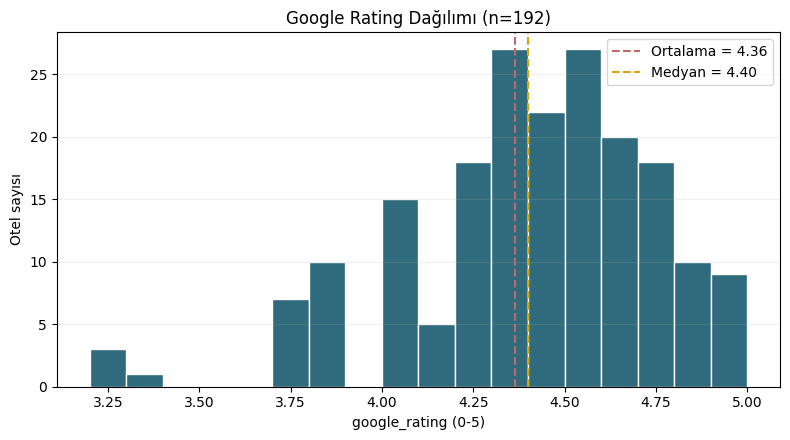

In [104]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["google_rating"].dropna(), bins=18, color=PRIMARY, edgecolor="white")
ax.axvline(df["google_rating"].mean(), color=ACCENT, linestyle="--", label=f"Ortalama = {df['google_rating'].mean():.2f}")
ax.axvline(df["google_rating"].median(), color=HIGHLIGHT, linestyle="--", label=f"Medyan = {df['google_rating'].median():.2f}")
ax.set(title="Google Rating Dağılımı (n=192)", xlabel="google_rating (0-5)", ylabel="Otel sayısı")
ax.grid(axis="y", alpha=0.2)
ax.legend()
save_fig(fig, "rating_distribution.png")
plt.show()

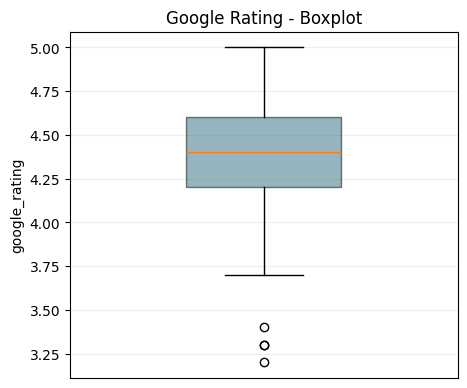

IQR fence: [3.60, 5.20] -> 4 olası uç değer


,hotel_name,area,google_rating,google_review_count
103,Greenport Bodrum,Güvercinlik,3.200,1317
27,Mira Beach Resort Bodrum,Bitez,3.300,274
36,Bodrum Bay Resort,Bodrum Merkez,3.300,1825
68,Siesta Beach Apart,Gümbet,3.400,502


In [105]:
fig, ax = plt.subplots(figsize=(5, 4.5))
bp = ax.boxplot(df["google_rating"].dropna(), vert=True, patch_artist=True, widths=0.4)
for box in bp["boxes"]:
    box.set(facecolor=PRIMARY, alpha=0.5)
ax.set(title="Google Rating - Boxplot", ylabel="google_rating")
ax.set_xticks([])
ax.grid(axis="y", alpha=0.2)
plt.show()

q1, q3 = df["google_rating"].quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
rating_outliers = df.loc[(df["google_rating"] < low_fence) | (df["google_rating"] > high_fence),
                          ["hotel_name", "area", "google_rating", "google_review_count"]]
print(f"IQR fence: [{low_fence:.2f}, {high_fence:.2f}] -> {len(rating_outliers)} olası uç değer")
display(rating_outliers.sort_values("google_rating"))

,hotel_count
google_rating,
<3.5,4
3.5-4.0,17
4.0-4.5,87
4.5-4.8,65
4.8+,19


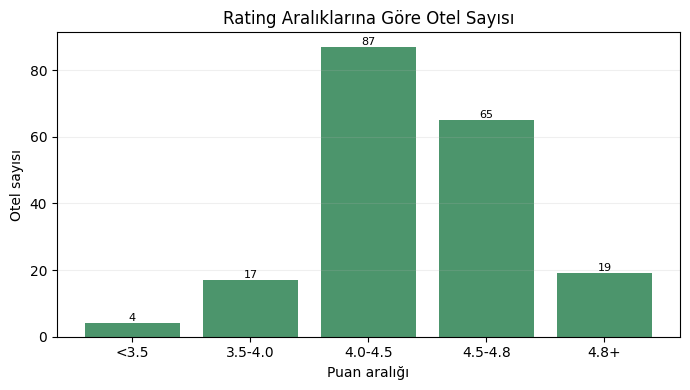

In [106]:
rating_bucket = pd.cut(
    df["google_rating"],
    bins=[0, 3.5, 4.0, 4.5, 4.8, 5.001],
    labels=["<3.5", "3.5-4.0", "4.0-4.5", "4.5-4.8", "4.8+"],
    right=False,
    include_lowest=True,
)
bucket_counts = rating_bucket.value_counts().reindex(["<3.5", "3.5-4.0", "4.0-4.5", "4.5-4.8", "4.8+"])
display(bucket_counts.to_frame(name="hotel_count"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bucket_counts.index.astype(str), bucket_counts.values, color=SECONDARY)
ax.set(title="Rating Aralıklarına Göre Otel Sayısı", xlabel="Puan aralığı", ylabel="Otel sayısı")
ax.grid(axis="y", alpha=0.2)
for i, v in enumerate(bucket_counts.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=8)
save_fig(fig, "rating_buckets.png")
plt.show()
# rating_bucket yalnızca bu hücre kapsamında geçicidir; df'e kalıcı olarak eklenmez.

**Bulgular — Rating**

- Google puanları sola çarpık (skew ≈ -0.72): çoğu otel 4.0-4.8 aralığında toplanıyor, düşük
  puanlı oteller (3.2-3.7) az sayıda ama belirgin bir kuyruk oluşturuyor.
- Ortalama (4.36) medyandan (4.40) az farklı düşük çıkıyor; bunun nedeni az sayıdaki düşük
  puanlı otelin ortalamayı aşağı çekmesi.
- IQR kuralına göre yalnızca düşük uçta uç değer var (~3.2-3.7 bandı); üst uçta 5.0 puanlı
  oteller IQR sınırını aşmıyor çünkü dağılım zaten üst banda yığılmış durumda.
- Otellerin çoğunluğu (4.0-4.8 arası) "iyi-çok iyi" bandında; bu, ileride bir rating modeli
  kurulacaksa sınıfların dengesiz olacağı anlamına gelir (çok az düşük puanlı örnek).

### 4. Google yorum sayısı dağılımı

**Soru:** Yorum sayısı (dijital görünürlük/popülerlik göstergesi) oteller arasında nasıl
dağılıyor? Az sayıda otel mi büyük yorum hacmini topluyor?


In [107]:
display(percentile_table(df["google_review_count"], "google_review_count"))

,feature,metric,value
0,google_review_count,count,192.000
1,google_review_count,missing,0.000
2,google_review_count,mean,"1,066.891"
3,google_review_count,std,"1,598.955"
4,google_review_count,min,33.000
5,google_review_count,p25,213.500
6,google_review_count,p50_median,466.000
7,google_review_count,p75,"1,322.750"
8,google_review_count,p90,"2,689.700"
9,google_review_count,p95,"3,862.900"


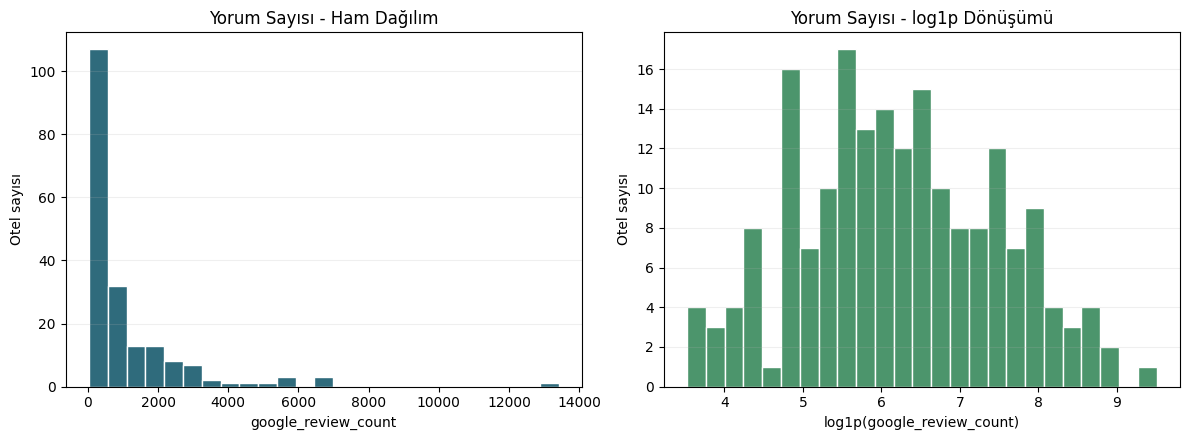

Ham dağılım çarpıklığı (skew): 3.71
log1p dağılımı çarpıklığı (skew): 0.11


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["google_review_count"], bins=25, color=PRIMARY, edgecolor="white")
axes[0].set(title="Yorum Sayısı - Ham Dağılım", xlabel="google_review_count", ylabel="Otel sayısı")
axes[0].grid(axis="y", alpha=0.2)

axes[1].hist(np.log1p(df["google_review_count"]), bins=25, color=SECONDARY, edgecolor="white")
axes[1].set(title="Yorum Sayısı - log1p Dönüşümü", xlabel="log1p(google_review_count)", ylabel="Otel sayısı")
axes[1].grid(axis="y", alpha=0.2)
save_fig(fig, "review_count_distribution.png")
plt.show()

print(f"Ham dağılım çarpıklığı (skew): {df['google_review_count'].skew():.2f}")
print(f"log1p dağılımı çarpıklığı (skew): {np.log1p(df['google_review_count']).skew():.2f}")

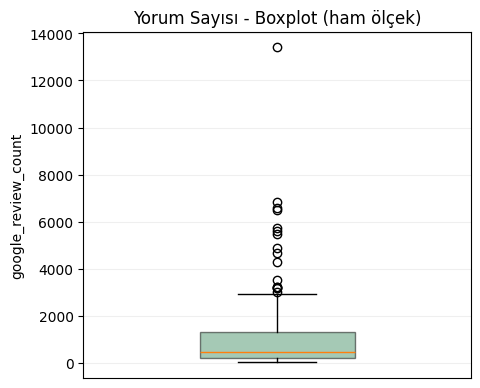

In [109]:
fig, ax = plt.subplots(figsize=(5, 4.5))
bp = ax.boxplot(df["google_review_count"], vert=True, patch_artist=True, widths=0.4)
for box in bp["boxes"]:
    box.set(facecolor=SECONDARY, alpha=0.5)
ax.set(title="Yorum Sayısı - Boxplot (ham ölçek)", ylabel="google_review_count")
ax.set_xticks([])
ax.grid(axis="y", alpha=0.2)
plt.show()

**Bulgular — Yorum Sayısı**

- Ham dağılım aşırı sağa çarpık (skew ≈ 4.9): medyan 466 iken maksimum 13.412 — birkaç otel
  toplam yorum hacminin büyük kısmını topluyor.
- log1p dönüşümü dağılımı belirgin biçimde normale yaklaştırıyor (skew ≈ 0'a çok daha yakın);
  bu nedenle rating ile ilişki incelenirken (Bölüm 7) ve modellerde yorum sayısı log ölçekte
  kullanılmalı.
- P90=2.690, P95=3.863: otellerin yalnızca %10'u 2.690'dan fazla yorum alıyor — popülerlik
  son derece az sayıda otelde yoğunlaşmış durumda.

### 5. En çok yorum alan oteller

**Soru:** Bodrum'da en yüksek dijital görünürlüğe / değerlendirme hacmine sahip oteller
hangileri?


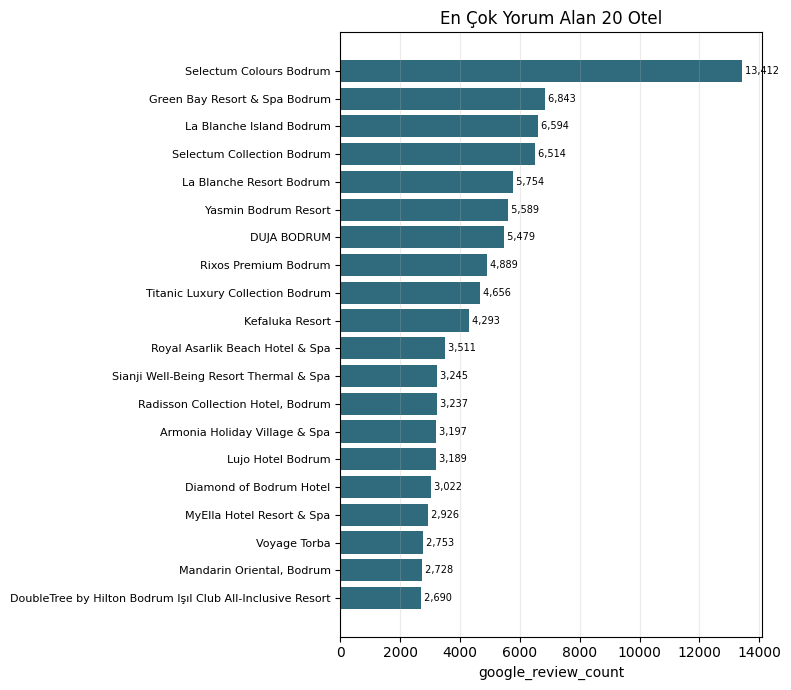

,hotel_name,area,google_review_count,google_rating
0,Selectum Colours Bodrum,Gümbet,13412,4.800
1,Green Bay Resort & Spa Bodrum,Güvercinlik,6843,4.500
2,La Blanche Island Bodrum,Güvercinlik,6594,4.300
3,Selectum Collection Bodrum,Akyarlar,6514,4.500
4,La Blanche Resort Bodrum,Turgutreis,5754,4.600
5,Yasmin Bodrum Resort,Kadıkalesi,5589,4.300
6,DUJA BODRUM,Torba,5479,4.400
7,Rixos Premium Bodrum,Torba,4889,4.700
8,Titanic Luxury Collection Bodrum,Güvercinlik,4656,4.600
9,Kefaluka Resort,Akyarlar,4293,4.400


In [110]:
top_reviewed = df.sort_values("google_review_count", ascending=False).head(20)
fig, ax = horizontal_bar(
    top_reviewed["hotel_name"].tolist(), top_reviewed["google_review_count"].tolist(),
    "En Çok Yorum Alan 20 Otel", "google_review_count", color=PRIMARY, figsize=(8, 7),
)
save_fig(fig, "hotels_by_review_count.png")
plt.show()

display(top_reviewed[["hotel_name", "area", "google_review_count", "google_rating"]].reset_index(drop=True))

**Bulgu:** En çok yorum alan oteller (Selectum Colours: 13.412, La Blanche Island: 6.594,
Green Bay Resort & Spa: 6.843 gibi) büyük ölçekli resort tipi tesisler ve birkaç bölgede
(Bodrum Merkez, Gümbet, Turgutreis çevresi) yoğunlaşıyor. Bu 20 otelin rating'leri 4.1-4.8
arasında değişiyor — yani en popüler oteller otomatik olarak en yüksek puanlı oteller değil
(bkz. Bölüm 7).

### 6. En yüksek puanlı oteller: ham puan mı, güvenilir puan mı?

5.0 puan + 20 yorum ile 4.8 puan + 10.000 yorum aynı güvenilirlik seviyesinde değildir. Bu
nedenle iki ayrı sıralama yapılır:

- **A.** Ham `google_rating`'e göre en yüksek puanlı oteller (yorum sayısı ne olursa olsun).
- **B.** En az `REVIEW_THRESHOLD` yorumu olan oteller arasında en yüksek puanlılar.

Eşik değeri: veri setinde yorum sayısının alt çeyreği (P25) ≈ 213'tür (Bölüm 4). Bu nedenle
**200** yorum, "en azından orta düzey bir kanıt tabanı" için makul ve yuvarlak bir eşik olarak
seçildi; bu değerin altındaki oteller tek tük yorumla yüksek puana ulaşmış olabilir.


In [111]:
REVIEW_THRESHOLD = 200

top_raw = df.sort_values(["google_rating", "google_review_count"], ascending=[False, False]).head(10)
print("A) Ham puana göre Top 10:")
display(top_raw[["hotel_name", "area", "google_rating", "google_review_count"]].reset_index(drop=True))

eligible = df.loc[df["google_review_count"] >= REVIEW_THRESHOLD]
top_reliable = eligible.sort_values(["google_rating", "google_review_count"], ascending=[False, False]).head(10)
print(f"\nB) En az {REVIEW_THRESHOLD} yorumu olan {len(eligible)} otel arasında Top 10:")
display(top_reliable[["hotel_name", "area", "google_rating", "google_review_count"]].reset_index(drop=True))

A) Ham puana göre Top 10:


,hotel_name,area,google_rating,google_review_count
0,Benjamin Otel,Gümüşlük,5.000,487
1,Gümüşlük No3,Gümüşlük,5.000,52
2,The Ni Villas Akyarlar,Akyarlar,5.000,44
3,Marje Villas,Gündoğan,5.000,33
4,"Radisson Collection Hotel, Bodrum",Akyarlar,4.900,3237
5,Sezz Hotels Spa Wellness Yalıkavak,Yalıkavak,4.900,114
6,Mumu Bodrum Hotel,Bitez,4.900,71
7,Ailla Yalıkavak,Yalıkavak,4.900,69
8,Gündoğan Suites,Gündoğan,4.900,67
9,Selectum Colours Bodrum,Gümbet,4.800,13412



B) En az 200 yorumu olan 147 otel arasında Top 10:


,hotel_name,area,google_rating,google_review_count
0,Benjamin Otel,Gümüşlük,5.000,487
1,"Radisson Collection Hotel, Bodrum",Akyarlar,4.900,3237
2,Selectum Colours Bodrum,Gümbet,4.800,13412
3,Mirada Exclusive Bodrum,Gümbet,4.800,1905
4,"Susona Bodrum, LXR Hotels & Resorts",Torba,4.800,886
5,Allium Bodrum Resort & Spa,Yalıkavak,4.800,528
6,Liman Hotel Gümüslük (Adult only),Gümüşlük,4.800,411
7,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,4.800,267
8,Rixos Premium Bodrum,Torba,4.700,4889
9,Voyage Torba,Torba,4.700,2753


**Bulgu:** Ham Top 10 listesinde yorum sayısı 33-3.237 arasında geniş bir aralığa yayılıyor;
örneğin Marje Villas (33 yorum) ve The Ni Villas Akyarlar (44 yorum) 5.0 puanla listede ama
kanıt tabanı çok ince. 200 yorum eşiği uygulandığında liste değişiyor ve daha büyük, istikrarlı
kanıt tabanına sahip oteller (Radisson Collection Hotel Bodrum, Selectum Colours Bodrum gibi)
öne çıkıyor. Bu ayrım, ileride "güvenilirlik ayarlı puan" (weighted/Bayesian rating) ihtiyacını
doğrudan gösteriyor — bkz. Bölüm 20 ve Key Findings.

#### 6.1 Google puanı 4'ün üzerinde olan oteller

Daha geniş bir referans olarak: kaç otel "4.0 üzeri" bandında ve bu otellerin yorum sayısı
(kanıt tabanı) nasıl dağılıyor?


In [112]:
above_four = df.loc[df["google_rating"] > 4.0]
print(f"google_rating > 4.0 olan otel sayısı: {len(above_four)} / {len(df)} (%{len(above_four) / len(df) * 100:.1f})")
display(percentile_table(above_four["google_review_count"], "google_review_count (rating>4 grubu)"))

print("\nBu gruptan yorum sayısına göre en görünür 15 otel:")
display(above_four.sort_values("google_review_count", ascending=False)
        [["hotel_name", "area", "google_rating", "google_review_count"]].head(15).reset_index(drop=True))

google_rating > 4.0 olan otel sayısı: 156 / 192 (%81.2)


,feature,metric,value
0,google_review_count (rating>4 grubu),count,156.000
1,google_review_count (rating>4 grubu),missing,0.000
2,google_review_count (rating>4 grubu),mean,"1,038.205"
3,google_review_count (rating>4 grubu),std,"1,711.644"
4,google_review_count (rating>4 grubu),min,33.000
5,google_review_count (rating>4 grubu),p25,193.000
6,google_review_count (rating>4 grubu),p50_median,399.000
7,google_review_count (rating>4 grubu),p75,994.250
8,google_review_count (rating>4 grubu),p90,"2,740.500"
9,google_review_count (rating>4 grubu),p95,"4,714.250"



Bu gruptan yorum sayısına göre en görünür 15 otel:


,hotel_name,area,google_rating,google_review_count
0,Selectum Colours Bodrum,Gümbet,4.800,13412
1,Green Bay Resort & Spa Bodrum,Güvercinlik,4.500,6843
2,La Blanche Island Bodrum,Güvercinlik,4.300,6594
3,Selectum Collection Bodrum,Akyarlar,4.500,6514
4,La Blanche Resort Bodrum,Turgutreis,4.600,5754
5,Yasmin Bodrum Resort,Kadıkalesi,4.300,5589
6,DUJA BODRUM,Torba,4.400,5479
7,Rixos Premium Bodrum,Torba,4.700,4889
8,Titanic Luxury Collection Bodrum,Güvercinlik,4.600,4656
9,Kefaluka Resort,Akyarlar,4.400,4293


**Bulgu:** Otellerin %81'i (156/192) 4.0 puanın üzerinde — bu bandın kendisi çok geniş olduğu
için "4 üzeri olmak" tek başına ayırt edici bir bilgi değil (Bölüm 3'teki bucket kırılımı daha
ayrıntılı bir kırılım sunuyor). Bu 156 otelin yorum sayısı da genel dağılımla aynı şekilde
aşırı çarpık: medyan 399 iken üst uçta 13.412'ye kadar çıkıyor; alt çeyrek yalnızca 193 yorumda
kalıyor. Yani "4 üzeri puanlı" bir otelin arkasında hem 33 yorumluk küçük bir bulgu hem de
13.000'i aşan yorumluk büyük bir kanıt tabanı olabilir — puanın kendisi bu farkı göstermiyor.

### 7. Google Puanı ile Yorum Sayısı Arasındaki İlişki: popüler oteller daha mı yüksek puanlı?

**Sorular:** Çok popüler oteller daha yüksek puan mı alıyor? Çok fazla yorum alan düşük puanlı
oteller var mı? Az yorumla çok yüksek puana sahip oteller var mı?

Yorum sayısı aşırı çarpık olduğundan x ekseni log ölçekte, **gerçek yorum sayılarıyla**
etiketlenmiş biçimde gösterilir (100, 1.000, 10.000 gibi — "log1p" gibi soyut bir dönüşüm
etiketi değil). Kırmızı kesikli çizgi doğrusal eğilimi, kutucuk Pearson/Spearman katsayılarını
gösterir. Pearson (doğrusal ilişki) ve Spearman (monotonik ilişki, aykırı değerlere daha
dayanıklı) ile hesaplanır.


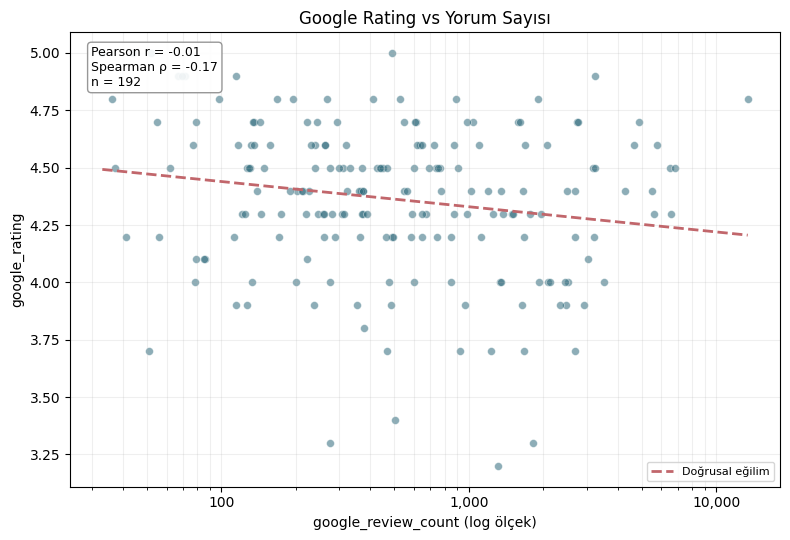

Pearson r (ham review_count): -0.007
Pearson r (log1p review_count): -0.181
Spearman rho (ham review_count): -0.174


In [113]:
fig, ax, pearson_r, spearman_r = relationship_scatter(
    df["google_review_count"], df["google_rating"],
    title="Google Rating vs Yorum Sayısı", xlabel="google_review_count (log ölçek)", ylabel="google_rating",
    color=PRIMARY, log_x=True,
)
save_fig(fig, "rating_vs_review_count.png")
plt.show()

pearson_r_log = df["review_count_log1p"].corr(df["google_rating"])
print(f"Pearson r (ham review_count): {pearson_r:.3f}")
print(f"Pearson r (log1p review_count): {pearson_r_log:.3f}")
print(f"Spearman rho (ham review_count): {spearman_r:.3f}")

**Bulgu:** Rating ile yorum sayısı arasındaki ilişki pratikte **yok denecek kadar zayıf ve hafif
negatif** (Pearson r ≈ -0.007 ham ölçekte, -0.18 log ölçekte; Spearman ρ ≈ -0.17). Yani "çok
popüler oteller otomatik olarak daha yüksek puanlı" varsayımı bu veri setinde desteklenmiyor —
tam tersine, çok yorum alan bazı büyük resortlar (bkz. Bölüm 5) orta seviye puanlarda kalıyor.
Bu **korelasyon değildir, nedensellik hiç değildir**: yorum sayısı fazlalığı otelin büyüklüğü,
kapasitesi ve pazarlama gücüyle de ilişkili olabilir. Zayıf ilişki, ham rating'in tek başına
güvenilir bir kalite göstergesi olmadığını, güvenilirlik ayarlı bir puanın (Bölüm 20) neden
gerekli olabileceğini destekliyor.

### 8. Konaklama tipi (property_category) analizi

**Soru:** Otel kategorileri arasında puan veya yorum hacmi farkı var mı?

Kategori dağılımı son derece dengesiz: `Otel` tek başına 174/192 satırı kapsıyor, geri kalan 12
kategori toplam 18 satıra yayılıyor ve bunların **11 tanesi tekil (n=1)** gözlemdir. Bu ölçüde
dengesiz bir dağılımda bar/boxplot grafiği yanıltıcı olur (tek bir dev çubuk + görünmez tekil
çubuklar, ya da n=1 kutulara sahip bir boxplot); bu nedenle burada **kasıtlı olarak grafik
üretilmiyor**, yalnızca sayısal tablo gösteriliyor.


In [114]:
category_counts = df["property_category"].value_counts()
display(category_counts.to_frame(name="hotel_count"))

small_categories = category_counts.loc[category_counts < 5].index
category_grouped = df["property_category"].where(~df["property_category"].isin(small_categories), "Diğer")
category_summary = df.assign(category_grouped=category_grouped).groupby("category_grouped").agg(
    hotel_count=("hotel_id", "size"),
    mean_rating=("google_rating", "mean"),
    median_rating=("google_rating", "median"),
    median_review_count=("google_review_count", "median"),
).sort_values("hotel_count", ascending=False)
print("5'ten az gözlemli kategoriler 'Diğer' altında toplanmış özet (yalnızca tablo, ana tabloya işlenmez):")
display(category_summary)

,hotel_count
property_category,
Otel,174
Resort Otel,5
Oda Kahvaltı,2
Uzun Süreli Kalmaya Uygun Otel,2
Villa,1
Turistik Pansiyon,1
Günlük Kiralık Daire,1
Kat Hizmeti Sunulan Konaklama,1
Motel,1


5'ten az gözlemli kategoriler 'Diğer' altında toplanmış özet (yalnızca tablo, ana tabloya işlenmez):


,hotel_count,mean_rating,median_rating,median_review_count
category_grouped,,,,
Otel,174,4.359,4.400,470.500
Diğer,13,4.415,4.400,171.000
Resort Otel,5,4.380,4.600,"1,575.000"


**Bulgular — Kategori**

- `Otel` (n=174) veri setine tamamen hakim; `Resort Otel` (n=5) tek başlı ikinci kategori.
  Geri kalan 11 kategori (Villa, Motel, Pansiyon, Apartments vb.) tekil örneklerden oluşuyor —
  bunlar hakkında istatistiksel genelleme yapılamaz, yalnızca bağlam olarak "Diğer" başlığı
  altında gösterildi.
- `Otel` (medyan 4.40) ile `Diğer` grubu (medyan 4.45) arasındaki fark tabloda küçük görünüyor;
  bunu istatistiksel olarak da test ediyoruz (Bölüm 30, Mann-Whitney): fark anlamlı bulunmuyor
  (p ≈ 0.46). Yani konaklama tipi tek başına güçlü bir rating ayırıcısı değil — ama örneklem
  dengesizliği (174'e karşı 18) bu sonucu temkinli okumayı gerektiriyor.
- `Resort Otel` grubu (n=5) medyan yorum sayısında diğer gruplara göre öne çıkıyor olabilir;
  ancak n=5 ile bu gözlem yalnızca bir eğilim, kesin bir kural değildir.

### 9. Destinasyonlara göre konaklama arzı

**Soru:** Bodrum'daki konaklama arzı hangi bölgelerde yoğunlaşıyor?


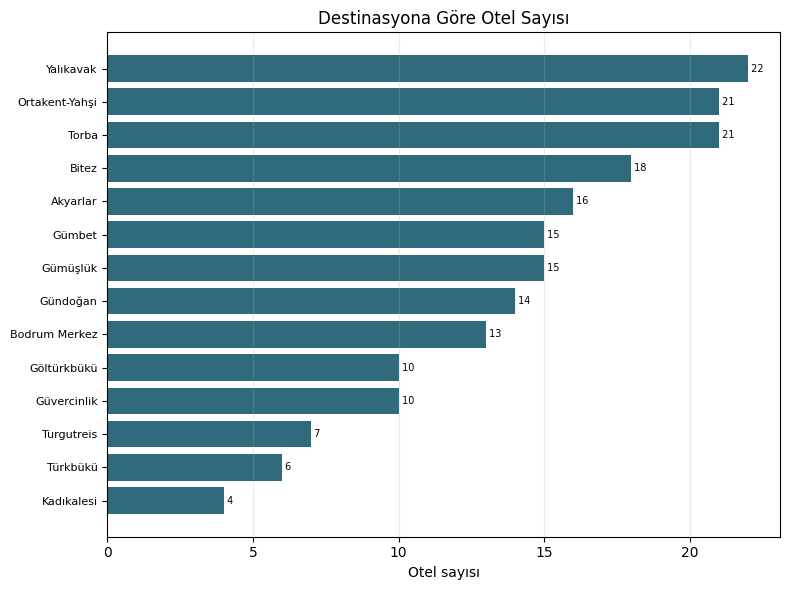

,hotel_count
area,
Yalıkavak,22
Ortakent-Yahşi,21
Torba,21
Bitez,18
Akyarlar,16
Gümbet,15
Gümüşlük,15
Gündoğan,14
Bodrum Merkez,13


In [115]:
area_counts = df["area"].value_counts()
fig, ax = horizontal_bar(
    area_counts.index.tolist(), area_counts.values.tolist(),
    "Destinasyona Göre Otel Sayısı", "Otel sayısı", color=PRIMARY, figsize=(8, 6),
)
save_fig(fig, "hotels_by_destination.png")
plt.show()
display(area_counts.to_frame(name="hotel_count"))

**Bulgu:** Arz üç bölgede yoğunlaşıyor: Yalıkavak (22), Ortakent-Yahşi (21) ve Torba (21) en
çok otele sahip destinasyonlar; bunları Bitez (18) izliyor. Diğer uçta Kadıkalesi (4) ve
Türkbükü (6) çok küçük örneklemli destinasyonlar — bu iki bölgeye ait her istatistik (ortalama,
medyan) aşağıdaki bölümlerde **açıkça küçük örneklem uyarısıyla** okunmalıdır.

### 10. Destinasyonların ortalama puanı

**Soru:** Hangi destinasyonlar müşteri memnuniyeti açısından öne çıkıyor? Sadece ortalamaya
güvenmek yeterli mi?


,hotel_count,avg_rating,median_rating
area,,,
Gündoğan,14,4.586,4.500
Gümüşlük,15,4.507,4.500
Göltürkbükü,10,4.480,4.450
Yalıkavak,22,4.464,4.450
Akyarlar,16,4.450,4.400
Türkbükü,6,4.450,4.450
Turgutreis,7,4.429,4.600
Torba,21,4.367,4.400
Bodrum Merkez,13,4.300,4.300


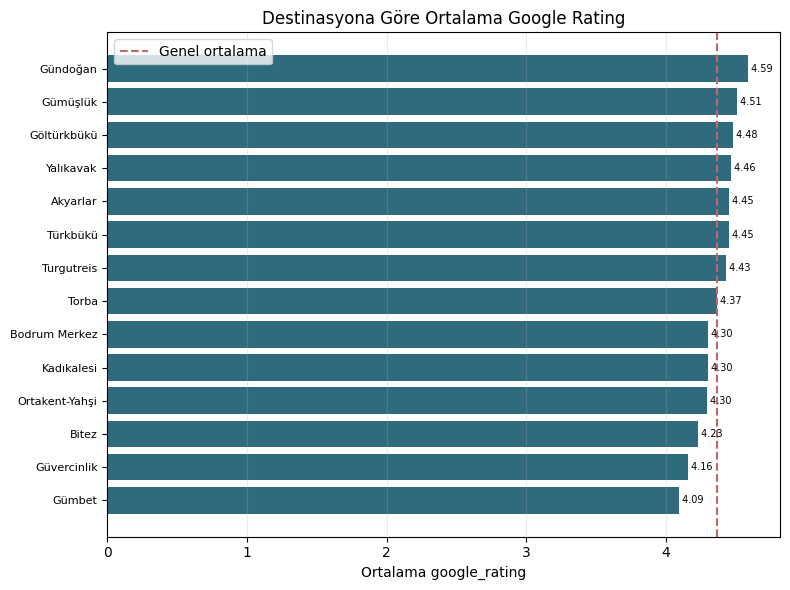

In [116]:
area_rating = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    avg_rating=("google_rating", "mean"),
    median_rating=("google_rating", "median"),
).sort_values("avg_rating", ascending=False)
display(area_rating)

fig, ax = horizontal_bar(
    area_rating.index.tolist(), area_rating["avg_rating"].tolist(),
    "Destinasyona Göre Ortalama Google Rating", "Ortalama google_rating",
    color=PRIMARY, figsize=(8, 6), value_fmt="{:.2f}",
)
ax.axvline(df["google_rating"].mean(), color=ACCENT, linestyle="--", label="Genel ortalama")
ax.legend()
save_fig(fig, "avg_rating_by_destination.png")
plt.show()

**Bulgu:** Gündoğan (4.59), Gümüşlük (4.51) ve Gündoğan çevresi genel ortalamanın (4.36) belirgin
üzerinde; Gümbet (4.09) ve Güvercinlik (4.16) ise en düşük ortalamaya sahip. Ancak Kadıkalesi
(n=4) ve Türkbükü (n=6) gibi küçük örneklemli bölgelerde tek bir düşük/yüksek puanlı otel
ortalamayı kolayca değiştirebilir — bu bölgelerdeki sıralama temkinli yorumlanmalı. Ortalama ile
medyan çoğu bölgede birbirine yakın; bu bölgesel dağılımların rating'te aşırı çarpık olmadığını
gösteriyor.

### 11. Destinasyon içi puan tutarlılığı

**Soru:** Aynı destinasyon içerisindeki oteller birbirine benziyor mu, yoksa ciddi kalite
farklılıkları var mı?


/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_38532/2991272722.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{g} (n={n})" for g, n in zip(order, counts)], patch_artist=True)


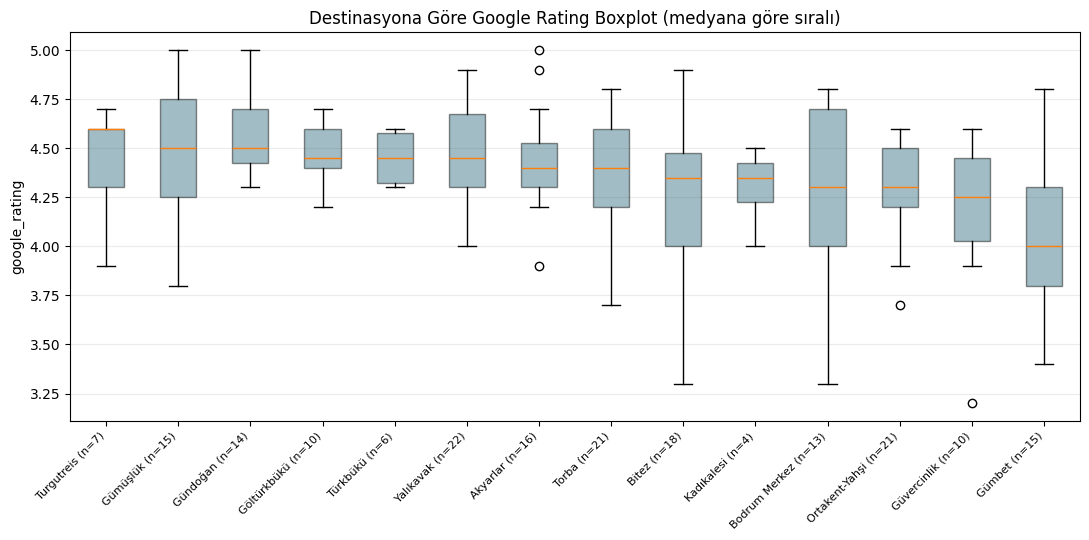

In [117]:
order_by_median = df.groupby("area")["google_rating"].median().sort_values(ascending=False).index.tolist()
fig, ax = grouped_boxplot(
    df, "area", "google_rating", order_by_median,
    "Destinasyona Göre Google Rating Boxplot (medyana göre sıralı)", "google_rating",
    figsize=(11, 5.5), color=PRIMARY,
)
save_fig(fig, "destination_rating_boxplot.png")
plt.show()

**Bulgu:** Kutu genişlikleri (IQR) bölgeler arasında benzer büyüklükte; hiçbir bölge tamamen
homojen değil — her destinasyonda hem yüksek hem düşük puanlı oteller bulunuyor. Gümbet ve
Ortakent-Yahşi gibi büyük örneklemli bölgelerde alt uç değerler (whisker altında kalan noktalar)
daha belirgin: bu bölgelerde kalite tutarsızlığı diğerlerine göre daha fazla. Küçük örneklemli
Kadıkalesi ve Türkbükü'nde kutular dar görünüyor ama bu istatistiksel güç eksikliğinden de
kaynaklanabilir, gerçek homojenlikten değil.

### 12. Destinasyon popülerliği: toplam mı, otel başına mı?

**Soru:** Hangi destinasyonlar en fazla dijital ilgiyi topluyor? Sadece toplam yorum sayısına
bakmak, otel sayısı fazla olan bölgeleri doğal olarak avantajlı gösterebilir — bu yüzden toplam
ve otel-başına-medyan ayrı değerlendirilir.


,hotel_count,total_reviews,median_reviews_per_hotel
area,,,
Gümbet,15,32519,"1,489.000"
Akyarlar,16,27426,"1,056.000"
Güvercinlik,10,25239,"1,082.500"
Torba,21,23707,372.000
Bodrum Merkez,13,18174,"1,575.000"
Turgutreis,7,14095,"1,608.000"
Bitez,18,12354,624.000
Kadıkalesi,4,11520,"2,683.000"
Ortakent-Yahşi,21,9874,261.000


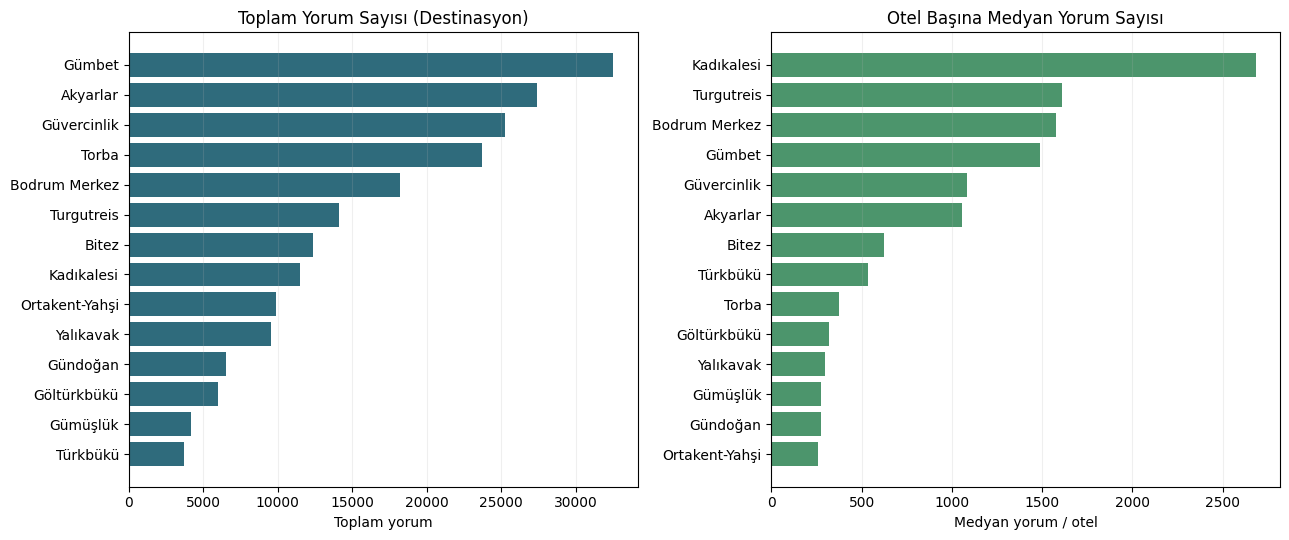

In [118]:
area_popularity = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    total_reviews=("google_review_count", "sum"),
    median_reviews_per_hotel=("google_review_count", "median"),
).sort_values("total_reviews", ascending=False)
display(area_popularity)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
order_total = area_popularity.sort_values("total_reviews").index.tolist()
axes[0].barh(order_total, area_popularity.loc[order_total, "total_reviews"], color=PRIMARY)
axes[0].set(title="Toplam Yorum Sayısı (Destinasyon)", xlabel="Toplam yorum")
axes[0].grid(axis="x", alpha=0.2)

order_median = area_popularity.sort_values("median_reviews_per_hotel").index.tolist()
axes[1].barh(order_median, area_popularity.loc[order_median, "median_reviews_per_hotel"], color=SECONDARY)
axes[1].set(title="Otel Başına Medyan Yorum Sayısı", xlabel="Medyan yorum / otel")
axes[1].grid(axis="x", alpha=0.2)
save_fig(fig, "destination_popularity_total_vs_median.png")
plt.show()

**Bulgu:** Toplam yorum sayısında Yalıkavak, Torba ve Bitez öne çıkıyor — ama bu büyük ölçüde
otel sayısı fazla olmalarından kaynaklanıyor. Otel başına medyan yorum sayısına bakıldığında
tablo değişiyor: Kadıkalesi (yalnızca 4 otel, medyan 2.683) ve Turgutreis (medyan 1.608) çok
daha popüler görünüyor. Bu, ölçek etkisini kontrol etmenin (toplam yerine medyan kullanmanın)
neden önemli olduğunu somut biçimde gösteriyor; ancak Kadıkalesi'nin n=4 olduğu unutulmamalı.

### 13. Destinasyon kalite-popülerlik matrisi

**Soru:** Hem popüler hem yüksek müşteri memnuniyetine sahip destinasyonlar hangileri?

Her nokta bir destinasyondur. X ekseni otel başına medyan yorum sayısı (popülerlik, ölçek etkisi
kontrollü), Y ekseni ortalama rating'dir. 14 destinasyonun kendi medyanları referans çizgisi
olarak kullanılır ve dört bölgeye ayrılır. **Bu, bir kümeleme (clustering) modeli değildir** —
yalnızca görsel bir EDA bölütlemesidir.


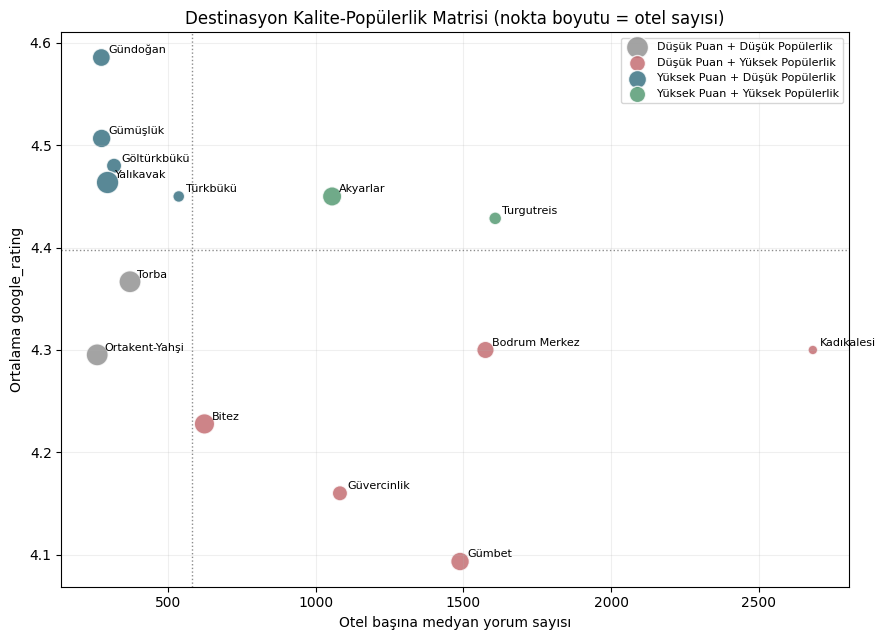

,area,hotel_count,avg_rating,median_reviews_per_hotel,quadrant
10,Torba,21,4.367,372.000,Düşük Puan + Düşük Popülerlik
9,Ortakent-Yahşi,21,4.295,261.000,Düşük Puan + Düşük Popülerlik
2,Bodrum Merkez,13,4.300,"1,575.000",Düşük Puan + Yüksek Popülerlik
8,Kadıkalesi,4,4.300,"2,683.000",Düşük Puan + Yüksek Popülerlik
1,Bitez,18,4.228,624.000,Düşük Puan + Yüksek Popülerlik
7,Güvercinlik,10,4.160,"1,082.500",Düşük Puan + Yüksek Popülerlik
4,Gümbet,15,4.093,"1,489.000",Düşük Puan + Yüksek Popülerlik
6,Gündoğan,14,4.586,275.000,Yüksek Puan + Düşük Popülerlik
5,Gümüşlük,15,4.507,276.000,Yüksek Puan + Düşük Popülerlik
3,Göltürkbükü,10,4.480,318.000,Yüksek Puan + Düşük Popülerlik


In [119]:
area_matrix = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    avg_rating=("google_rating", "mean"),
    median_reviews_per_hotel=("google_review_count", "median"),
).reset_index()

x_ref = area_matrix["median_reviews_per_hotel"].median()
y_ref = area_matrix["avg_rating"].median()

def classify(row):
    rating_label = "Yüksek Puan" if row["avg_rating"] >= y_ref else "Düşük Puan"
    pop_label = "Yüksek Popülerlik" if row["median_reviews_per_hotel"] >= x_ref else "Düşük Popülerlik"
    return f"{rating_label} + {pop_label}"

area_matrix["quadrant"] = area_matrix.apply(classify, axis=1)

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = {"Yüksek Puan + Yüksek Popülerlik": SECONDARY, "Yüksek Puan + Düşük Popülerlik": PRIMARY,
          "Düşük Puan + Yüksek Popülerlik": ACCENT, "Düşük Puan + Düşük Popülerlik": NEUTRAL}
for quadrant, group in area_matrix.groupby("quadrant"):
    ax.scatter(group["median_reviews_per_hotel"], group["avg_rating"], s=group["hotel_count"] * 12,
               color=colors.get(quadrant, NEUTRAL), alpha=0.8, label=quadrant, edgecolor="white")
for _, row in area_matrix.iterrows():
    ax.annotate(row["area"], (row["median_reviews_per_hotel"], row["avg_rating"]), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.axvline(x_ref, color=NEUTRAL, linestyle=":", linewidth=1)
ax.axhline(y_ref, color=NEUTRAL, linestyle=":", linewidth=1)
ax.set(title="Destinasyon Kalite-Popülerlik Matrisi (nokta boyutu = otel sayısı)",
       xlabel="Otel başına medyan yorum sayısı", ylabel="Ortalama google_rating")
ax.grid(alpha=0.2)
ax.legend(fontsize=8, loc="best")
save_fig(fig, "destination_popularity_vs_rating.png")
plt.show()

display(area_matrix.sort_values(["quadrant", "avg_rating"], ascending=[True, False])
        [["area", "hotel_count", "avg_rating", "median_reviews_per_hotel", "quadrant"]])

**Bulgular — Destinasyon**

- **Yüksek Puan + Yüksek Popülerlik** çeyreğinde yalnızca Akyarlar ve Turgutreis yer alıyor —
  hem müşteri memnuniyeti hem dijital ilgi açısından "ideal" destinasyonlar bunlar.
- Yalıkavak, Gümüşlük, Gündoğan, Göltürkbükü ve Türkbükü **Yüksek Puan + Düşük Popülerlik**
  çeyreğinde: memnuniyet yüksek ama otel başına görece az yorum birikmiş — bunlar "gizli
  kalmış" ya da nispeten yeni/bilinirliği düşük destinasyonlar olabilir.
- Gümbet, Bodrum Merkez, Bitez, Güvercinlik ve Kadıkalesi **Düşük Puan + Yüksek Popülerlik**
  çeyreğinde: yoğun ilgi görüyor ama memnuniyet görece düşük — kapasite/kitle turizmi baskısı
  bir hipotez olabilir, bu veriyle kanıtlanamaz.
- Torba ve Ortakent-Yahşi **Düşük Puan + Düşük Popülerlik** çeyreğinde kalıyor.

### 14. Fiyat snapshot genel istatistikleri

**Önemli bağlam:** `search_price_usd_snapshot`, otelin sabit/kalıcı fiyatı **değildir**. Bu
alan yalnızca **2026-08-24 tarihli tek bir arama snapshot'ıdır**; oda tipi, konaklama süresi,
kişi sayısı ve rezervasyon koşulları bilinmemektedir. Bu bölüm ve devamındaki fiyat analizleri
yalnızca o anki arama bağlamını yansıtır; kalıcı bir "otel fiyatı" olarak yorumlanmamalıdır.
Ayrıntılı fiyat analizi `06_price_analysis.ipynb` içinde yapılacaktır — burada yalnızca sınırlı
genel bağlam verilir.


In [120]:
display(percentile_table(df["search_price_usd_snapshot"], "search_price_usd_snapshot"))
q1, q3 = df["search_price_usd_snapshot"].quantile([0.25, 0.75])
print(f"IQR: {q3 - q1:.1f} USD")
print(f"Fiyat çarpıklığı (skew): {df['search_price_usd_snapshot'].skew():.2f}")

,feature,metric,value
0,search_price_usd_snapshot,count,168.000
1,search_price_usd_snapshot,missing,24.000
2,search_price_usd_snapshot,mean,291.506
3,search_price_usd_snapshot,std,414.470
4,search_price_usd_snapshot,min,57.000
5,search_price_usd_snapshot,p25,117.000
6,search_price_usd_snapshot,p50_median,168.000
7,search_price_usd_snapshot,p75,301.750
8,search_price_usd_snapshot,p90,481.300
9,search_price_usd_snapshot,p95,822.550


IQR: 184.8 USD
Fiyat çarpıklığı (skew): 4.61


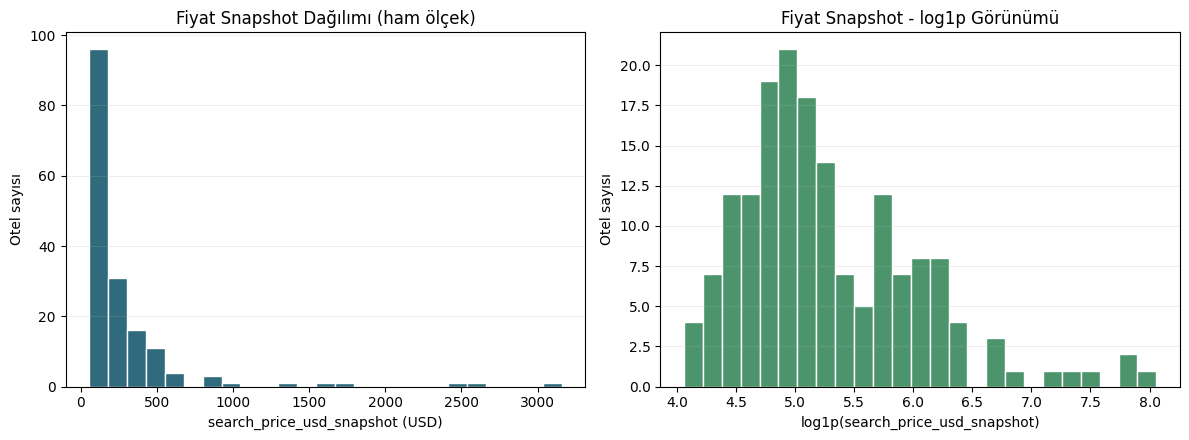

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["search_price_usd_snapshot"].dropna(), bins=25, color=PRIMARY, edgecolor="white")
axes[0].set(title="Fiyat Snapshot Dağılımı (ham ölçek)", xlabel="search_price_usd_snapshot (USD)", ylabel="Otel sayısı")
axes[0].grid(axis="y", alpha=0.2)

axes[1].hist(np.log1p(df["search_price_usd_snapshot"].dropna()), bins=25, color=SECONDARY, edgecolor="white")
axes[1].set(title="Fiyat Snapshot - log1p Görünümü", xlabel="log1p(search_price_usd_snapshot)", ylabel="Otel sayısı")
axes[1].grid(axis="y", alpha=0.2)
save_fig(fig, "price_distribution.png")
plt.show()

**Bulgu:** Fiyat snapshot'ı 168/192 otelde mevcut (24 otelde yok, doldurulmadı). Dağılım aşırı
sağa çarpık (skew ≈ 4.6): medyan 168 USD iken maksimum 3.158 USD — az sayıda üst segment otel
ortalamayı ciddi biçimde yukarı çekiyor (ortalama 292 USD, medyandan çok yüksek). Bu, fiyatla
ilgili her analizde medyanın ortalamadan daha güvenilir bir merkezi eğilim ölçüsü olduğunu
gösteriyor.

### 15. En yüksek fiyat snapshot'ına sahip oteller

**Not:** Aşağıdaki sıralama bir "en pahalı otel" listesi değil, **tek bir arama anındaki en
yüksek fiyat snapshot'ı** listesidir.


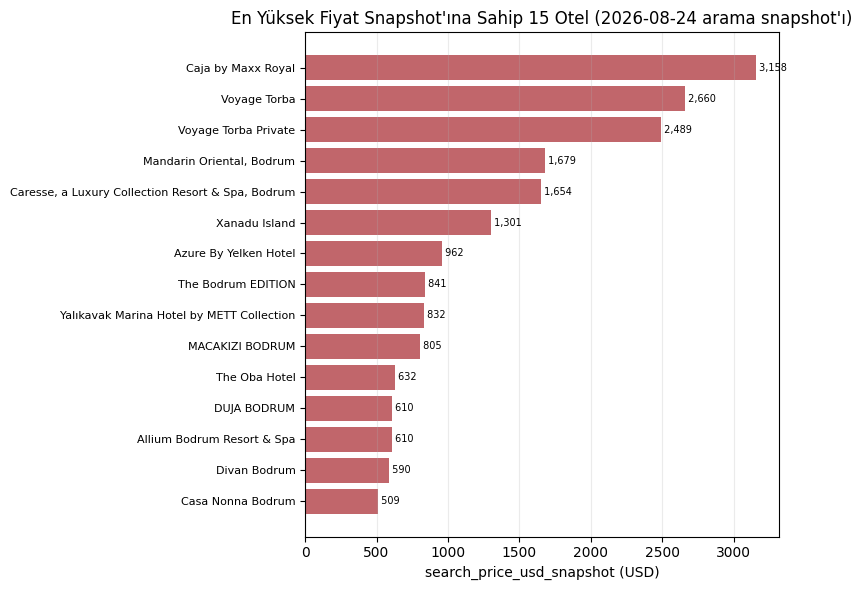

,hotel_name,area,search_price_usd_snapshot,google_rating,google_review_count
0,Caja by Maxx Royal,Türkbükü,"3,158.000",4.600,135
1,Voyage Torba,Torba,"2,660.000",4.700,2753
2,Voyage Torba Private,Torba,"2,489.000",4.700,548
3,"Mandarin Oriental, Bodrum",Göltürkbükü,"1,679.000",4.700,2728
4,"Caresse, a Luxury Collection Resort & Spa, Bodrum",Bitez,"1,654.000",4.500,904
5,Xanadu Island,Akyarlar,"1,301.000",4.600,2068
6,Azure By Yelken Hotel,Kadıkalesi,962.000,4.400,565
7,The Bodrum EDITION,Yalıkavak,841.000,4.400,1016
8,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,832.000,4.800,267
9,MACAKIZI BODRUM,Türkbükü,805.000,4.300,1247


In [122]:
top_price = df.dropna(subset=["search_price_usd_snapshot"]).sort_values("search_price_usd_snapshot", ascending=False).head(15)
fig, ax = horizontal_bar(
    top_price["hotel_name"].tolist(), top_price["search_price_usd_snapshot"].tolist(),
    "En Yüksek Fiyat Snapshot'ına Sahip 15 Otel (2026-08-24 arama snapshot'ı)",
    "search_price_usd_snapshot (USD)", color=ACCENT, figsize=(8, 6),
)
save_fig(fig, "highest_price_hotels.png")
plt.show()

display(top_price[["hotel_name", "area", "search_price_usd_snapshot", "google_rating", "google_review_count"]].reset_index(drop=True))

**Bulgu:** En yüksek fiyat snapshot'ına sahip 15 otelin rating'leri 4.4-4.8 arasında yüksek ve
tutarlı — bu segmentte düşük puanlı otel görünmüyor. Coğrafi olarak Torba (Voyage Torba,
Mandarin Oriental) ve Yalıkavak (Yalıkavak Marina Hotel by METT Collection) öne çıkıyor. Ancak
bu 15 otelin çoğu tek bir snapshot anına ait fiyat gösteriyor; sezonsallık veya oda tipi farkı
bu sıralamayı değiştirebilir.

### 16. Fiyat ile Google Puanı Arasındaki İlişki

**Sorular:** Daha pahalı oteller gerçekten daha yüksek puanlı mı? Pahalı fakat düşük puanlı
oteller var mı? Uygun fiyatlı yüksek puanlı oteller var mı?

Önce fiyatı dört anlaşılır aralığa (bucket) bölüp her aralığın ortalama/medyan puanını
karşılaştırıyoruz — bu, tek tek 168 noktayı okumaktan çok daha kolay bir özet verir. Ardından,
aynı ilişkiyi otel bazında (nokta grafiği + eğilim çizgisi + korelasyon) gösteriyoruz.


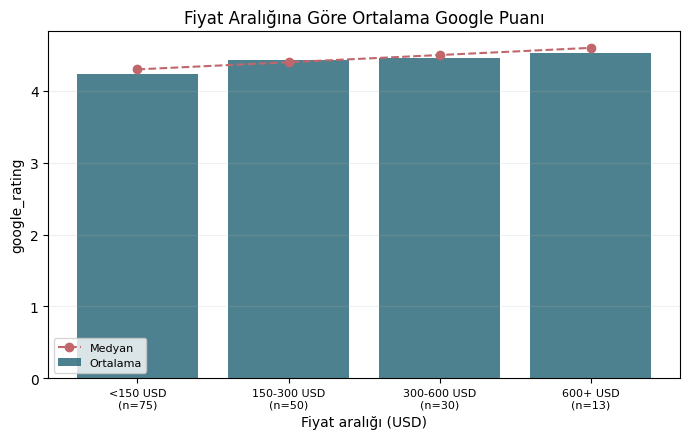

,mean,median,count
price_bucket,,,
<150 USD,4.240,4.300,75
150-300 USD,4.430,4.400,50
300-600 USD,4.460,4.500,30
600+ USD,4.530,4.600,13


In [123]:
price_bucket_bins = [0, 150, 300, 600, np.inf]
price_bucket_labels = ["<150 USD", "150-300 USD", "300-600 USD", "600+ USD"]
price_bucket = pd.cut(df["search_price_usd_snapshot"], bins=price_bucket_bins, labels=price_bucket_labels)

fig, ax, price_bucket_summary = bucket_bar(
    df.assign(price_bucket=price_bucket).dropna(subset=["price_bucket"]),
    "price_bucket", "google_rating",
    "Fiyat Aralığına Göre Ortalama Google Puanı", "Fiyat aralığı (USD)", "google_rating",
    color=PRIMARY,
)
save_fig(fig, "price_bucket_vs_rating.png")
plt.show()
display(price_bucket_summary.round(2))

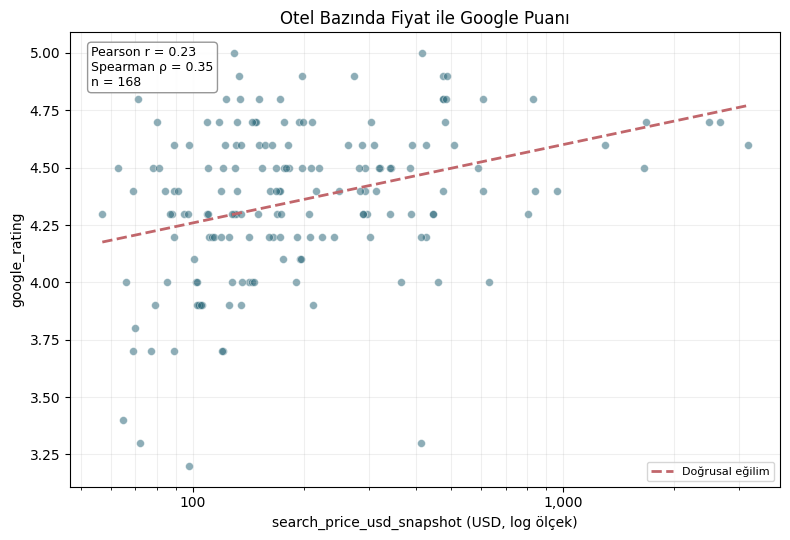

Pearson r: 0.234
Spearman rho: 0.348


In [124]:
fig, ax, price_rating_pearson, price_rating_spearman = relationship_scatter(
    df["search_price_usd_snapshot"], df["google_rating"],
    title="Otel Bazında Fiyat ile Google Puanı", xlabel="search_price_usd_snapshot (USD, log ölçek)",
    ylabel="google_rating", color=PRIMARY, log_x=True,
)
save_fig(fig, "price_vs_rating.png")
plt.show()

print(f"Pearson r: {price_rating_pearson:.3f}")
print(f"Spearman rho: {price_rating_spearman:.3f}")

**Bulgu:** Bucket grafiği ilişkiyi net gösteriyor: <150 USD bandındaki otellerin ortalama puanı
en düşük, 600+ USD bandındaki otellerin ortalama puanı en yüksek — ortalama puan fiyat
arttıkça kademeli olarak yükseliyor. Otel bazındaki nokta grafiği ve korelasyon bunu doğruluyor:
fiyat ile rating arasında zayıf-orta düzeyde **pozitif** bir ilişki var (Pearson r ≈ 0.23,
Spearman ρ ≈ 0.35). Yani pahalı otellerin ortalamada biraz daha yüksek puanlı olma eğilimi var,
ama ilişki güçlü değil — grafikteki geniş dağılım, her fiyat bandında hem yüksek hem düşük
puanlı örneklerin bulunduğunu gösteriyor. Bu **nedensellik değildir** — fiyat, rating'i değil,
muhtemelen her ikisini de etkileyen konum/segment gibi ortak faktörleri yansıtıyor olabilir.

### 17. Fiyat ile Yorum Sayısı Arasındaki İlişki

**Soru:** Daha pahalı oteller daha fazla dijital ilgi mi görüyor?


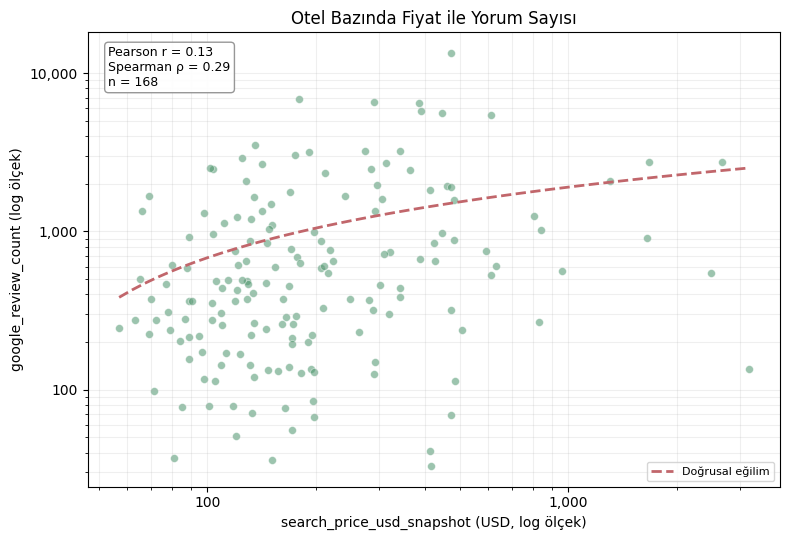

Pearson r: 0.127
Spearman rho: 0.287


In [125]:
fig, ax, price_review_pearson, price_review_spearman = relationship_scatter(
    df["search_price_usd_snapshot"], df["google_review_count"],
    title="Otel Bazında Fiyat ile Yorum Sayısı", xlabel="search_price_usd_snapshot (USD, log ölçek)",
    ylabel="google_review_count (log ölçek)", color=SECONDARY, log_x=True,
)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:,.0f}"))
save_fig(fig, "price_vs_review_count.png")
plt.show()

print(f"Pearson r: {price_review_pearson:.3f}")
print(f"Spearman rho: {price_review_spearman:.3f}")

**Bulgu:** İlişki oldukça zayıf (Pearson r ≈ 0.13). Fiyat, dijital popülerliğin güçlü bir
belirleyicisi değil — bazı yüksek fiyatlı butik oteller az yorumla (küçük kapasite, düşük
doluluk hacmi) görünürken, bazı orta/düşük fiyatlı büyük resortlar binlerce yorum topluyor
(bkz. Bölüm 5).

### 18. Destinasyona göre fiyat

**Soru:** Fiyat snapshot'ı bölgeler arasında nasıl farklılaşıyor? Hangi bölgelerde yeterli fiyat
gözlemi var?


In [126]:
area_price = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    price_n=("search_price_usd_snapshot", lambda s: s.notna().sum()),
    median_price=("search_price_usd_snapshot", "median"),
    mean_price=("search_price_usd_snapshot", "mean"),
).sort_values("median_price", ascending=False)
area_price["price_coverage_pct"] = (area_price["price_n"] / area_price["hotel_count"] * 100).round(1)
display(area_price)

low_coverage = area_price.loc[area_price["price_n"] < 5]
if not low_coverage.empty:
    print(f"Uyarı: {list(low_coverage.index)} bölgelerinde 5'ten az fiyat gözlemi var; medyan bu bölgelerde temkinli okunmalı.")

,hotel_count,price_n,median_price,mean_price,price_coverage_pct
area,,,,,
Türkbükü,6,6,532.000,956.000,100.000
Kadıkalesi,4,3,446.000,583.667,75.000
Yalıkavak,22,22,329.500,355.045,100.000
Torba,21,17,248.000,532.647,81.000
Akyarlar,16,12,192.500,284.417,75.000
Gündoğan,14,14,189.500,211.214,100.000
Bodrum Merkez,13,13,169.000,242.846,100.000
Göltürkbükü,10,10,165.000,311.900,100.000
Güvercinlik,10,8,162.500,195.625,80.000


Uyarı: ['Kadıkalesi'] bölgelerinde 5'ten az fiyat gözlemi var; medyan bu bölgelerde temkinli okunmalı.


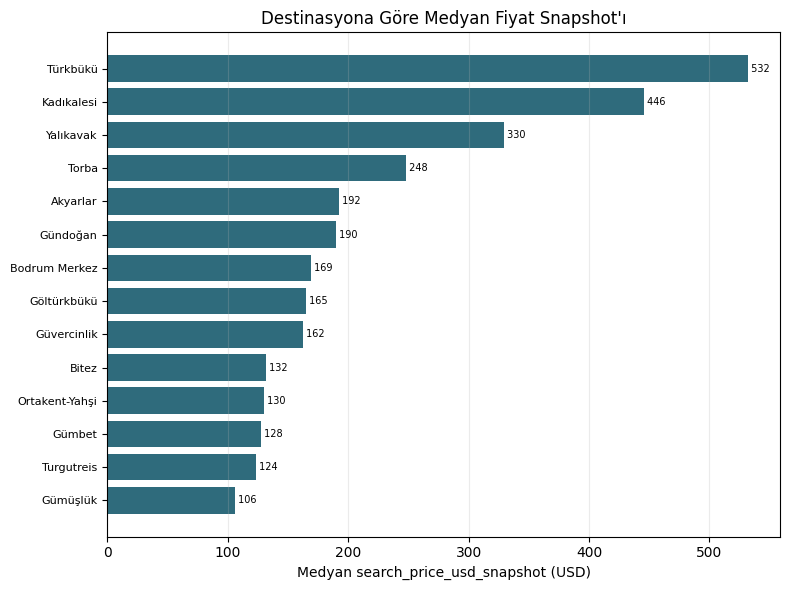

/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_38532/2991272722.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{g} (n={n})" for g, n in zip(order, counts)], patch_artist=True)


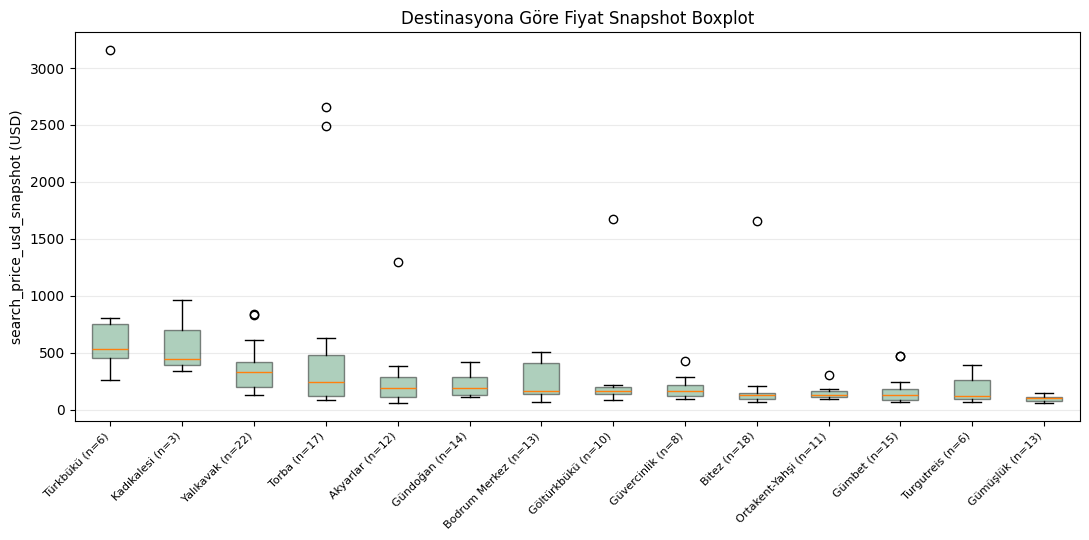

In [127]:
fig, ax = horizontal_bar(
    area_price.index.tolist(), area_price["median_price"].tolist(),
    "Destinasyona Göre Medyan Fiyat Snapshot'ı", "Medyan search_price_usd_snapshot (USD)",
    color=PRIMARY, figsize=(8, 6), value_fmt="{:.0f}",
)
save_fig(fig, "median_price_by_destination.png")
plt.show()

price_order = area_price.sort_values("median_price", ascending=False).index.tolist()
fig, ax = grouped_boxplot(
    df, "area", "search_price_usd_snapshot", price_order,
    "Destinasyona Göre Fiyat Snapshot Boxplot", "search_price_usd_snapshot (USD)",
    figsize=(11, 5.5), color=SECONDARY,
)
save_fig(fig, "price_distribution_by_area.png")
plt.show()

**Bulgu:** Türkbükü (medyan 532 USD, yalnızca 6 otel) ve Kadıkalesi (446 USD, yalnızca 3 fiyat
gözlemi) en yüksek medyan fiyatı gösteriyor — ama ikisi de çok küçük örneklem. Daha büyük ve
güvenilir örneklemli bölgeler arasında Yalıkavak (329 USD, 22 gözlem) en yüksek medyanlı
"premium" destinasyon. Gümüşlük (106 USD) ve Gümbet (128 USD) en uygun fiyatlı büyük
örneklemli bölgeler. Boxplot'lar özellikle Yalıkavak ve Torba'da geniş bir fiyat aralığı
olduğunu gösteriyor — bu bölgeler hem bütçe hem lüks segmenti bir arada barındırıyor.

### 19. Destinasyon Bazında Fiyat ile Memnuniyet İlişkisi

**Soru:** Premium fiyatlı destinasyonlar gerçekten daha yüksek müşteri memnuniyeti sunuyor mu?


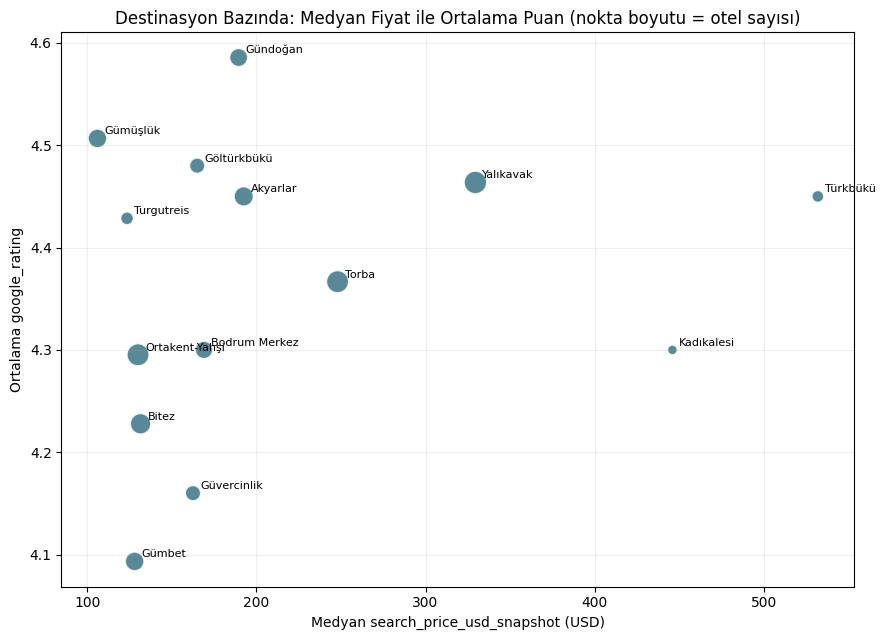

Destinasyon düzeyinde (n=14) Pearson r: 0.183


In [128]:
area_price_rating = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    avg_rating=("google_rating", "mean"),
    median_price=("search_price_usd_snapshot", "median"),
).dropna(subset=["median_price"])

corr_area = area_price_rating["median_price"].corr(area_price_rating["avg_rating"])

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(area_price_rating["median_price"], area_price_rating["avg_rating"],
           s=df.groupby("area")["hotel_id"].size().reindex(area_price_rating.index) * 12,
           color=PRIMARY, alpha=0.8, edgecolor="white")
for area_name, row in area_price_rating.iterrows():
    ax.annotate(area_name, (row["median_price"], row["avg_rating"]), fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set(title="Destinasyon Bazında: Medyan Fiyat ile Ortalama Puan (nokta boyutu = otel sayısı)",
       xlabel="Medyan search_price_usd_snapshot (USD)", ylabel="Ortalama google_rating")
ax.grid(alpha=0.2)
save_fig(fig, "destination_price_vs_rating.png")
plt.show()

print(f"Destinasyon düzeyinde (n=14) Pearson r: {corr_area:.3f}")

**Bulgu:** Destinasyon düzeyinde fiyat ile ortalama rating arasındaki ilişki çok zayıf (r ≈
0.18, n=14). Gündoğan ve Gümüşlük görece düşük/orta medyan fiyatla en yüksek ortalama puanı
alırken, yüksek medyan fiyatlı Türkbükü ve Kadıkalesi ortalama puanda üst sırada değil. Bu,
"daha pahalı = daha memnun müşteri" varsayımının destinasyon düzeyinde de desteklenmediğini
gösteriyor — ama n=14 ile bu ilişkinin gücü hakkında kesin yargıya varmak zor.

### 20. Rating tek başına yeterli mi? Review confidence örnekleri

Rating tek başına yanıltıcı olabilir: az yorumlu bir 5.0 ile binlerce yorumlu bir 4.5 aynı
"güven" seviyesinde değildir. Burada **kalıcı bir Bayesian/weighted skor üretilmiyor** —
`04_feature_engineering.ipynb` içinde zaten hesaplanmış olan `weighted_google_rating`
kolonundan (yorum hacmine göre genel ortalamaya daraltılmış puan) yalnızca örnekleme/keşif
amacıyla yararlanılıyor. **Uyarı:** bu kolon doğrudan `google_rating`'den türetildiği için bir
rating tahmin modelinde girdi olarak kullanılırsa target leakage yaratır (bkz. feature
dictionary); burada yalnızca EDA yorumlama amaçlıdır.

Üç örnek grup incelenir: yüksek rating + yüksek yorum sayısı, yüksek rating + düşük yorum
sayısı, düşük rating + yüksek yorum sayısı.


In [129]:
rating_med = df["google_rating"].median()
review_med = df["google_review_count"].median()

high_high = df.loc[(df["google_rating"] >= rating_med) & (df["google_review_count"] >= review_med)]
high_low = df.loc[(df["google_rating"] >= rating_med) & (df["google_review_count"] < review_med)]
low_high = df.loc[(df["google_rating"] < rating_med) & (df["google_review_count"] >= review_med)]

cols = ["hotel_name", "area", "google_rating", "google_review_count", "weighted_google_rating"]
print(f"Yüksek rating + Yüksek yorum (n={len(high_high)}) - örnek 5:")
display(high_high.sort_values("google_review_count", ascending=False)[cols].head(5))

print(f"\nYüksek rating + Düşük yorum (n={len(high_low)}) - örnek 5 (weighted rating en çok düşenler):")
display(high_low.assign(diff=(high_low["google_rating"] - high_low["weighted_google_rating"]))
        .sort_values("diff", ascending=False)[cols].head(5))

print(f"\nDüşük rating + Yüksek yorum (n={len(low_high)}) - örnek 5:")
display(low_high.sort_values("google_review_count", ascending=False)[cols].head(5))

Yüksek rating + Yüksek yorum (n=48) - örnek 5:


,hotel_name,area,google_rating,google_review_count,weighted_google_rating
67,Selectum Colours Bodrum,Gümbet,4.800,13412,4.785
102,Green Bay Resort & Spa Bodrum,Güvercinlik,4.500,6843,4.491
11,Selectum Collection Bodrum,Akyarlar,4.500,6514,4.491
159,La Blanche Resort Bodrum,Turgutreis,4.600,5754,4.582
140,DUJA BODRUM,Torba,4.400,5479,4.397



Yüksek rating + Düşük yorum (n=58) - örnek 5 (weighted rating en çok düşenler):


,hotel_name,area,google_rating,google_review_count,weighted_google_rating
93,Marje Villas,Gündoğan,5.000,33,4.406
14,The Ni Villas Akyarlar,Akyarlar,5.000,44,4.418
75,Gümüşlük No3,Gümüşlük,5.000,52,4.427
90,Gündoğan Suites,Gündoğan,4.900,67,4.431
171,Ailla Yalıkavak,Yalıkavak,4.900,69,4.433



Düşük rating + Yüksek yorum (n=48) - örnek 5:


,hotel_name,area,google_rating,google_review_count,weighted_google_rating
105,La Blanche Island Bodrum,Güvercinlik,4.300,6594,4.304
114,Yasmin Bodrum Resort,Kadıkalesi,4.300,5589,4.305
65,Royal Asarlik Beach Hotel & Spa,Gümbet,4.000,3511,4.043
1,Armonia Holiday Village & Spa,Akyarlar,4.200,3197,4.221
39,Diamond of Bodrum Hotel,Bodrum Merkez,4.100,3022,4.135


**Bulgu:** "Yüksek rating + düşük yorum" grubundaki oteller için `weighted_google_rating`, ham
puandan belirgin biçimde düşük çıkıyor (örn. Mira Beach Resort Bodrum'da fark ~0.67 puana kadar
çıkabiliyor) — az yorumlu yüksek puanların genel ortalamaya doğru "daraltılması" gerektiğini
somut olarak gösteriyor. Bu, ham `google_rating` sıralamasının (Bölüm 6-A) neden tek başına
yanıltıcı olabileceğini doğruluyor ve ileride kalıcı bir güvenilirlik ayarlı puanın (Bayesian /
weighted rating) Feature Engineering'e resmi olarak eklenip eklenmeyeceği sorusunu gündeme
getiriyor (bkz. Questions for Next Stages).

### 21. Hangi destinasyonlarda hangi konaklama tipleri yoğunlaşıyor?

`property_category` × `area` çapraz tablosu, konaklama tipi çeşitliliğinin bölgeler arasında
nasıl dağıldığını gösterir. Bölüm 8'de görüldüğü gibi `Otel` dışındaki kategoriler zaten
neredeyse tamamen tekil (n=1) gözlemlerden oluştuğu için bir ısı haritası/grafik yerine
doğrudan sayısal tablo tercih edildi — bir grafik, gerçekte var olmayan bir örüntü izlenimi
verebilirdi.


In [130]:
category_area_pivot = pd.crosstab(df["area"], df["property_category"])
display(category_area_pivot)

property_category,Apartments,Doğa Köşkü,Günlük Kiralık Daire,Kamping Bungalov,Kat Hizmeti Sunulan Konaklama,Konaklama Tesisi,Motel,Oda Kahvaltı,Otel,Resort Otel,Turistik Pansiyon,Uzun Süreli Kalmaya Uygun Otel,Villa
area,,,,,,,,,,,,,
Akyarlar,0,0,0,0,0,0,0,0,15,0,0,0,1
Bitez,0,0,0,0,0,0,0,1,17,0,0,0,0
Bodrum Merkez,0,0,0,0,0,0,0,0,12,1,0,0,0
Göltürkbükü,0,0,1,0,0,0,0,0,8,0,1,0,0
Gümbet,0,0,0,0,1,0,1,0,11,1,0,1,0
Gümüşlük,1,1,0,1,0,0,0,1,10,0,0,1,0
Gündoğan,0,0,0,0,0,0,0,0,14,0,0,0,0
Güvercinlik,0,0,0,0,0,0,0,0,10,0,0,0,0
Kadıkalesi,0,0,0,0,0,1,0,0,3,0,0,0,0


**Bulgu:** `Otel` kategorisi neredeyse tüm bölgelerde baskın konaklama tipi ve bu nedenle
tabloyu domine ediyor. Alternatif tipler (Villa, Motel, Pansiyon, Apartments vb.) yalnızca tek
tük bölgede ve genellikle tek örnekle görünüyor — örn. `Resort Otel` etiketi Bitez, Bodrum
Merkez, Gümbet, Ortakent-Yahşi ve Torba'ya dağılmış durumda. Konaklama tipi çeşitliliği düşük;
bu, "destinasyon profili" çıkarımının (Bölüm 32) büyük ölçüde `Otel` kategorisine dayanacağı,
ve bölge×kategori kırılımında ortalama rating karşılaştırmasının (ör. "Bitez'deki Resort
Otel'ler mi daha iyi puanlı?") bu veri setiyle güvenilir biçimde yapılamayacağı anlamına
geliyor — bunun için Villa/Pansiyon/Resort kategorilerinde daha fazla örnek toplanması gerekir.

### 22. Sayısal değişkenler arası korelasyon

Kullanılabilir sayısal kolonlar: `google_rating`, `google_review_count`,
`search_price_usd_snapshot`. `official_star_rating` veri setinde tamamen eksik olduğu için
(Bölüm 23) korelasyon matrisine dahil edilmiyor. Hem Pearson (doğrusal) hem Spearman
(monotonik) hesaplanır. **Korelasyon nedensellik değildir** — burada yalnızca ilişkilerin
yönü ve gücü betimlenir.


/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_38532/2991272722.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


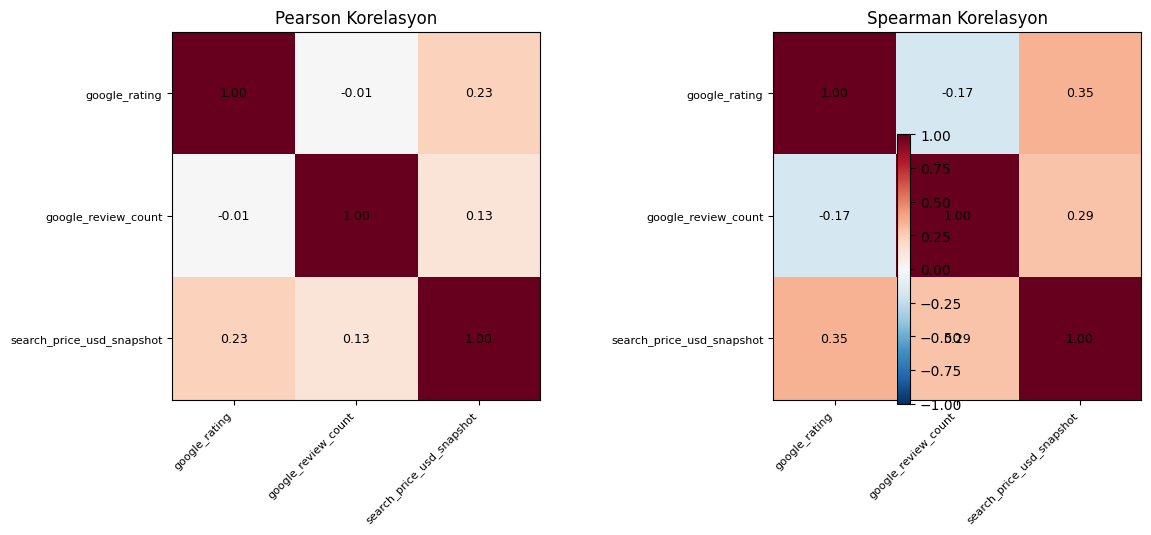

,google_rating,google_review_count,search_price_usd_snapshot
google_rating,1.000,-0.007,0.234
google_review_count,-0.007,1.000,0.127
search_price_usd_snapshot,0.234,0.127,1.000


,google_rating,google_review_count,search_price_usd_snapshot
google_rating,1.000,-0.174,0.348
google_review_count,-0.174,1.000,0.287
search_price_usd_snapshot,0.348,0.287,1.000


In [131]:
numeric_cols = ["google_rating", "google_review_count", "search_price_usd_snapshot"]
pearson_matrix = df[numeric_cols].corr(method="pearson")
spearman_matrix = df[numeric_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title in zip(axes, [pearson_matrix, spearman_matrix], ["Pearson", "Spearman"]):
    im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols, fontsize=8)
    ax.set_title(f"{title} Korelasyon")
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f"{matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.7)
save_fig(fig, "correlation_heatmap.png")
plt.show()

display(pearson_matrix)
display(spearman_matrix)

**Bulgu:** Üç değişken arasında da **güçlü korelasyon yok**. En belirgin ilişki fiyat-rating
arasında (Spearman ρ ≈ 0.35, zayıf-orta) ve zaten Bölüm 16'da tartışıldı. Rating ile yorum
sayısı arasındaki ilişki neredeyse sıfır/hafif negatif (Bölüm 7). Bu, üç değişkenin büyük
ölçüde **birbirinden bağımsız bilgi taşıdığı** anlamına geliyor — ileride bir model kurulacaksa
bu değişkenlerin çoklu doğrusal bağlantı (multicollinearity) riski taşımadığı, her birinin ayrı
sinyal katabileceği söylenebilir.

### 23. Resmî yıldız sınıfı

**Veri yeterliliği kontrolü:** `official_star_rating`, veri setindeki **192 kaydın tamamında**
eksiktir (bkz. KPI tablosu, Bölüm 2). Bu nedenle yıldız-rating, yıldız-fiyat ve yıldız-yorum
karşılaştırmaları **yapılamaz**. Google puanından resmî yıldız türetmek proje kurallarına
aykırıdır; bu alan yalnızca "veri yok" olarak bırakılır ve ileride doğrulanmış dış kaynakla
(örn. Kültür ve Turizm Bakanlığı belgeli işletme listesi) zenginleştirilmesi gerektiği not
edilir.


In [132]:
star_available = df["official_star_rating"].notna().sum()
print(f"official_star_rating dolu kayıt sayısı: {star_available} / {len(df)}")
print("Yıldız sınıfının rating, fiyat ve yorum sayısıyla karşılaştırılması, veri yetersizliği nedeniyle atlanmıştır.")

official_star_rating dolu kayıt sayısı: 0 / 192
Yıldız sınıfının rating, fiyat ve yorum sayısıyla karşılaştırılması, veri yetersizliği nedeniyle atlanmıştır.


### 24. Business status

**Veri yeterliliği kontrolü:** `business_status`, 191/192 kayıtta eksik; yalnızca 1 otelde dolu
değer var. Bu, **istatistiksel bir "açık otel oranı" veya "kapalı otel oranı" çıkarımı için
yetersizdir**. Proje kuralı gereği eksiklik "otel kapalı" anlamına gelmez — yalnızca bu bilginin
toplanmadığı/mevcut olmadığı anlamına gelir. Bu nedenle burada yalnızca mevcut tek değer
gösterilir, başka grafik veya karşılaştırma üretilmez.


In [133]:
display(df["business_status"].value_counts(dropna=False).to_frame(name="count"))
display(df.loc[df["business_status"].notna(), ["hotel_id", "hotel_name", "area", "business_status"]])

,count
business_status,
NaN,191
Temporarily Closed,1


,hotel_id,hotel_name,area,business_status
144,BOD145,Moyo Luxury Hotel & Beach,Torba,Temporarily Closed


**Bulgu:** Veri setinde yalnızca 1 otel (`business_status` dolu) bilgiye sahip; kalan 191 otel
için bu alan basitçe **toplanmamış**. Bu otelin varlığı, geri kalan 191 otelin "açık" olduğu
anlamına gelmez — yalnızca bu tek kayıt için Google'dan bu bilginin döndüğü anlamına gelir.
Sonuç olarak business status bu veri setinde anlamlı bir analiz değişkeni değildir.

### 25. Temizlik sonrası kalan eksiklikler

Bu bölüm `02_data_audit.ipynb`'i tekrarlamaz; yalnızca EDA'yı etkileyebilecek kalan
eksiklikleri özetler. Temizleme aşamasında hiçbir değer doldurulmadığı için eksiklik oranları
ham veriyle aynıdır.


,column,missing_count,missing_percentage
0,official_star_rating,192,100.000
1,business_status,191,99.500
2,search_price_usd_snapshot,24,12.500
3,phone,4,2.100


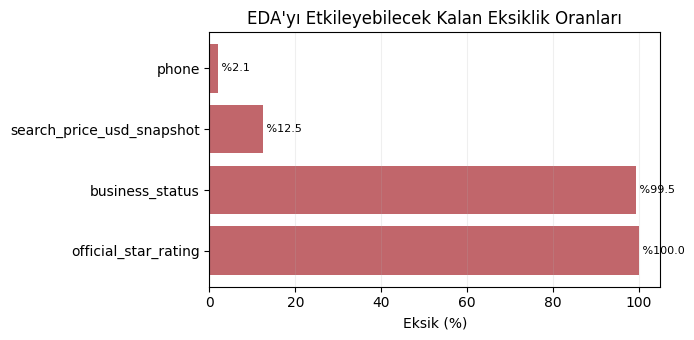

In [134]:
missing_recap = pd.DataFrame({
    "column": ["official_star_rating", "business_status", "search_price_usd_snapshot", "phone"],
    "missing_count": [
        (~df["has_official_star_rating"]).sum(),
        (~df["has_business_status"]).sum(),
        (~df["has_price_snapshot"]).sum(),
        (~df["has_phone"]).sum(),
    ],
})
missing_recap["missing_percentage"] = (missing_recap["missing_count"] / len(df) * 100).round(1)
display(missing_recap)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(missing_recap["column"], missing_recap["missing_percentage"], color=ACCENT)
ax.set(title="EDA'yı Etkileyebilecek Kalan Eksiklik Oranları", xlabel="Eksik (%)")
ax.grid(axis="x", alpha=0.2)
for y, v in enumerate(missing_recap["missing_percentage"]):
    ax.text(v, y, f" %{v}", va="center", fontsize=8)
save_fig(fig, "remaining_missingness.png")
plt.show()

**Bulgu:** `official_star_rating` (%100) ve `business_status` (%99.5) pratik olarak
analiz dışı; `search_price_usd_snapshot` (%12.5) fiyat bölümlerinde satır bazında düşüşe neden
oluyor ama genel örneklemi bozacak kadar yüksek değil; `phone` (%2.1) bu EDA'yı etkilemiyor.

### 26. Potansiyel uç değer (outlier) oteller

Herhangi bir model kullanılmadan basit istatistiksel eşiklerle (IQR / persentil) dikkat çeken
oteller listelenir. Bu bir anomali tespiti değildir, yalnızca gözlemsel bir işaretlemedir.


In [135]:
print("Rating açısından düşük uç (<=3.5):")
display(df.loc[df["google_rating"] <= 3.5, ["hotel_name", "area", "google_rating", "google_review_count"]]
        .sort_values("google_rating"))

p95_reviews = df["google_review_count"].quantile(0.95)
print(f"\nYorum sayısı açısından aşırı yüksek (>P95={p95_reviews:.0f}):")
display(df.loc[df["google_review_count"] > p95_reviews, ["hotel_name", "area", "google_review_count", "google_rating"]]
        .sort_values("google_review_count", ascending=False))

p95_price = df["search_price_usd_snapshot"].quantile(0.95)
print(f"\nFiyat snapshot'ı açısından aşırı yüksek (>P95={p95_price:.0f} USD):")
display(df.loc[df["search_price_usd_snapshot"] > p95_price, ["hotel_name", "area", "search_price_usd_snapshot", "google_rating"]]
        .sort_values("search_price_usd_snapshot", ascending=False))

Rating açısından düşük uç (<=3.5):


,hotel_name,area,google_rating,google_review_count
103,Greenport Bodrum,Güvercinlik,3.200,1317
27,Mira Beach Resort Bodrum,Bitez,3.300,274
36,Bodrum Bay Resort,Bodrum Merkez,3.300,1825
68,Siesta Beach Apart,Gümbet,3.400,502



Yorum sayısı açısından aşırı yüksek (>P95=3863):


,hotel_name,area,google_review_count,google_rating
67,Selectum Colours Bodrum,Gümbet,13412,4.800
102,Green Bay Resort & Spa Bodrum,Güvercinlik,6843,4.500
105,La Blanche Island Bodrum,Güvercinlik,6594,4.300
11,Selectum Collection Bodrum,Akyarlar,6514,4.500
159,La Blanche Resort Bodrum,Turgutreis,5754,4.600
114,Yasmin Bodrum Resort,Kadıkalesi,5589,4.300
140,DUJA BODRUM,Torba,5479,4.400
147,Rixos Premium Bodrum,Torba,4889,4.700
109,Titanic Luxury Collection Bodrum,Güvercinlik,4656,4.600
6,Kefaluka Resort,Akyarlar,4293,4.400



Fiyat snapshot'ı açısından aşırı yüksek (>P95=823 USD):


,hotel_name,area,search_price_usd_snapshot,google_rating
164,Caja by Maxx Royal,Türkbükü,"3,158.000",4.600
155,Voyage Torba,Torba,"2,660.000",4.700
156,Voyage Torba Private,Torba,"2,489.000",4.700
55,"Mandarin Oriental, Bodrum",Göltürkbükü,"1,679.000",4.700
20,"Caresse, a Luxury Collection Resort & Spa, Bodrum",Bitez,"1,654.000",4.500
15,Xanadu Island,Akyarlar,"1,301.000",4.600
111,Azure By Yelken Hotel,Kadıkalesi,962.000,4.400
188,The Bodrum EDITION,Yalıkavak,841.000,4.400
190,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,832.000,4.800


**Bulgu:** Düşük rating uç değerleri (4 otel, 3.2-3.5 arası) çoğunlukla yüksek yorum sayısına
sahip (274-1.825 arası) — yani bu düşük puanlar az sayıda yorumun tesadüfi sonucu değil,
görece geniş bir kanıt tabanına dayanıyor. Aşırı yorum sayısı ve aşırı fiyat uçlarındaki
oteller birbirinden farklı gruplar (kesişim yok); bu da "popüler" ile "pahalı" olmanın bu veri
setinde ayrı boyutlar olduğunu bir kez daha doğruluyor (Bölüm 17, 22).

### 27. Otel düzeyinde Rating x Popülerlik matrisi

X: `google_review_count` (log ölçek), Y: `google_rating`. Medyan değerler referans alınarak
dört çeyreğe ayrılır: Yüksek Rating + Yüksek Popülerlik, Yüksek Rating + Düşük Popülerlik,
Düşük Rating + Yüksek Popülerlik, Düşük Rating + Düşük Popülerlik. **Bu bir kümeleme modeli
değildir**, yalnızca medyan tabanlı görsel bir EDA bölütlemesidir.


,hotel_count
hotel_quadrant,
Yüksek Rating + Düşük Popülerlik,58
Düşük Rating + Yüksek Popülerlik,48
Yüksek Rating + Yüksek Popülerlik,48
Düşük Rating + Düşük Popülerlik,38


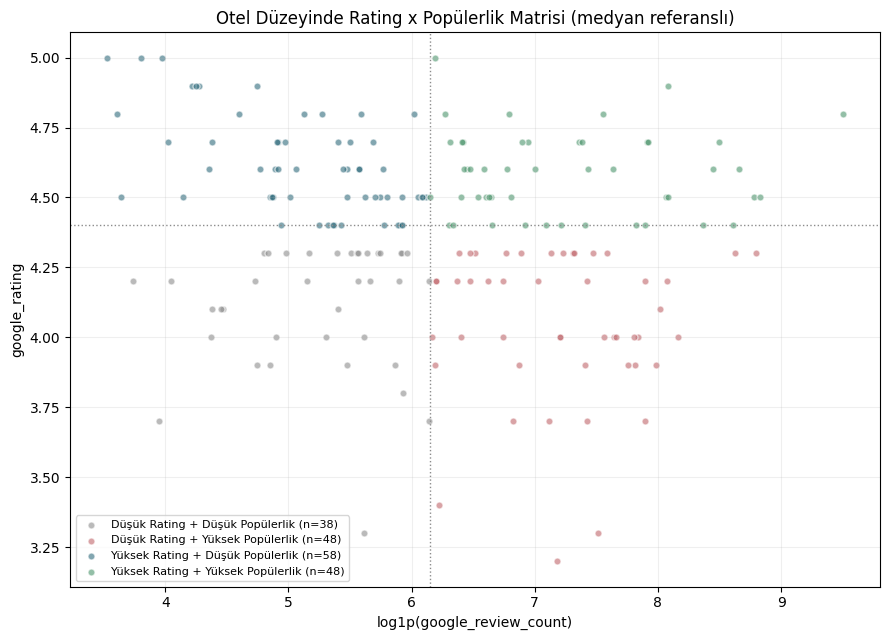


Yüksek Rating + Düşük Popülerlik - örnek oteller:


,hotel_name,area,google_rating,google_review_count
125,Khai Hotel Bodrum,Ortakent-Yahşi,4.500,452
81,Otel Gümüşlük,Gümüşlük,4.500,442
174,Avantgarde Refined Hotel | Yalıkavak,Yalıkavak,4.500,437



Düşük Rating + Yüksek Popülerlik - örnek oteller:


,hotel_name,area,google_rating,google_review_count
105,La Blanche Island Bodrum,Güvercinlik,4.300,6594
114,Yasmin Bodrum Resort,Kadıkalesi,4.300,5589
65,Royal Asarlik Beach Hotel & Spa,Gümbet,4.000,3511



Yüksek Rating + Yüksek Popülerlik - örnek oteller:


,hotel_name,area,google_rating,google_review_count
67,Selectum Colours Bodrum,Gümbet,4.800,13412
102,Green Bay Resort & Spa Bodrum,Güvercinlik,4.500,6843
11,Selectum Collection Bodrum,Akyarlar,4.500,6514



Düşük Rating + Düşük Popülerlik - örnek oteller:


,hotel_name,area,google_rating,google_review_count
58,Bodrum Hotel Baba,Gümbet,3.700,465
182,Ruins Luxury Resort,Yalıkavak,4.200,462
177,Highlight Hotel Yalıkavak,Yalıkavak,4.300,387


In [136]:
rating_med = df["google_rating"].median()
review_med = df["google_review_count"].median()

def hotel_quadrant(row):
    r = "Yüksek Rating" if row["google_rating"] >= rating_med else "Düşük Rating"
    p = "Yüksek Popülerlik" if row["google_review_count"] >= review_med else "Düşük Popülerlik"
    return f"{r} + {p}"

df_quadrant = df.assign(hotel_quadrant=df.apply(hotel_quadrant, axis=1))
quadrant_counts = df_quadrant["hotel_quadrant"].value_counts()
display(quadrant_counts.to_frame(name="hotel_count"))

colors_q = {"Yüksek Rating + Yüksek Popülerlik": SECONDARY, "Yüksek Rating + Düşük Popülerlik": PRIMARY,
            "Düşük Rating + Yüksek Popülerlik": ACCENT, "Düşük Rating + Düşük Popülerlik": NEUTRAL}
fig, ax = plt.subplots(figsize=(9, 6.5))
for quadrant, group in df_quadrant.groupby("hotel_quadrant"):
    ax.scatter(group["review_count_log1p"], group["google_rating"], color=colors_q.get(quadrant, NEUTRAL),
               alpha=0.6, s=25, label=f"{quadrant} (n={len(group)})", edgecolor="white")
ax.axvline(np.log1p(review_med), color=NEUTRAL, linestyle=":", linewidth=1)
ax.axhline(rating_med, color=NEUTRAL, linestyle=":", linewidth=1)
ax.set(title="Otel Düzeyinde Rating x Popülerlik Matrisi (medyan referanslı)",
       xlabel="log1p(google_review_count)", ylabel="google_rating")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
save_fig(fig, "hotel_quadrant_rating_popularity.png")
plt.show()

for quadrant in quadrant_counts.index:
    print(f"\n{quadrant} - örnek oteller:")
    display(df_quadrant.loc[df_quadrant["hotel_quadrant"] == quadrant]
            .sort_values("google_review_count", ascending=False)
            [["hotel_name", "area", "google_rating", "google_review_count"]].head(3))

**Bulgu:** Dört çeyrek de kayda değer büyüklükte (38-58 otel arası) — yani veri setinde tek bir
baskın profil yok, oteller rating ve popülerlik açısından oldukça karışık dağılıyor. "Yüksek
Rating + Düşük Popülerlik" en kalabalık çeyrek (58 otel): küçük/butik ama memnuniyeti yüksek
oteller. "Düşük Rating + Yüksek Popülerlik" çeyreğinde (48 otel) La Blanche Island Bodrum (6.594
yorum, düşük puan) gibi büyük ölçekli oteller var — yüksek hacim her zaman yüksek memnuniyet
getirmiyor. Bu dörtlü yapı, ileride bir segmentasyon/kümeleme çalışmasının (K-Means vb.)
üzerine kurulabileceği doğal bir başlangıç noktası.

### 28. Fiyat x Rating matrisi

Yalnızca fiyat snapshot'ı bulunan 168 otel için, medyan fiyat ve medyan rating referans alınarak
dört çeyreğe ayrılır. Özellikle **Düşük Fiyat + Yüksek Rating** çeyreği ileride fiyat/performans
analizi için önemlidir — ancak burada henüz resmi bir `value_score` **üretilmiyor**.


,hotel_count
price_quadrant,
Yüksek Fiyat + Yüksek Rating,57
Düşük Fiyat + Düşük Rating,48
Düşük Fiyat + Yüksek Rating,35
Yüksek Fiyat + Düşük Rating,28


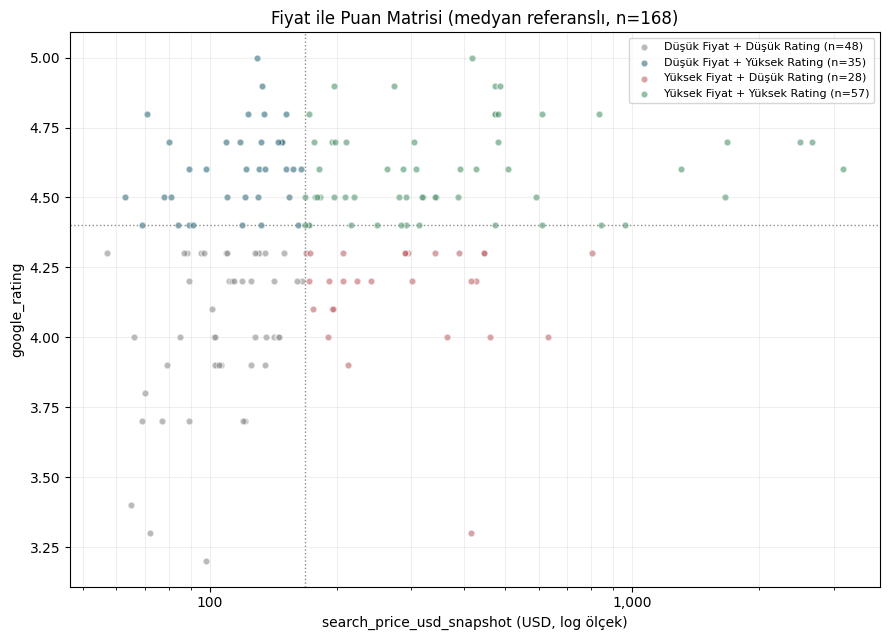


Düşük Fiyat + Yüksek Rating (n=35) - en yüksek puanlı 10 örnek:


,hotel_name,area,search_price_usd_snapshot,google_rating,google_review_count
74,Benjamin Otel,Gümüşlük,129.000,5.000,487
28,Mumu Bodrum Hotel,Bitez,133.000,4.900,71
77,Liman Hotel Gümüslük (Adult only),Gümüşlük,134.000,4.800,411
98,Villa Oliva Butik Otel,Gündoğan,123.000,4.800,168
43,Noa Suite Hotel,Bodrum Merkez,71.000,4.800,98
73,Begonvil Gümüşlük,Gümüşlük,151.000,4.800,36
45,Senses Hotel,Bodrum Merkez,148.000,4.700,1035
86,Wanderheaven Camping & Tiny House Bodrum,Gümüşlük,80.000,4.700,613
99,Villa Rustica Hotel,Gündoğan,145.000,4.700,243
47,Babana Hotel,Göltürkbükü,132.000,4.700,221


In [137]:
price_df = df.dropna(subset=["search_price_usd_snapshot"]).copy()
price_med = price_df["search_price_usd_snapshot"].median()
rating_med_p = price_df["google_rating"].median()

def price_quadrant(row):
    p = "Yüksek Fiyat" if row["search_price_usd_snapshot"] >= price_med else "Düşük Fiyat"
    r = "Yüksek Rating" if row["google_rating"] >= rating_med_p else "Düşük Rating"
    return f"{p} + {r}"

price_df["price_quadrant"] = price_df.apply(price_quadrant, axis=1)
display(price_df["price_quadrant"].value_counts().to_frame(name="hotel_count"))

colors_pq = {"Yüksek Fiyat + Yüksek Rating": SECONDARY, "Düşük Fiyat + Yüksek Rating": PRIMARY,
             "Yüksek Fiyat + Düşük Rating": ACCENT, "Düşük Fiyat + Düşük Rating": NEUTRAL}
fig, ax = plt.subplots(figsize=(9, 6.5))
for quadrant, group in price_df.groupby("price_quadrant"):
    ax.scatter(group["search_price_usd_snapshot"], group["google_rating"], color=colors_pq.get(quadrant, NEUTRAL),
               alpha=0.6, s=25, label=f"{quadrant} (n={len(group)})", edgecolor="white")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:,.0f}"))
ax.axvline(price_med, color=NEUTRAL, linestyle=":", linewidth=1)
ax.axhline(rating_med_p, color=NEUTRAL, linestyle=":", linewidth=1)
ax.set(title="Fiyat ile Puan Matrisi (medyan referanslı, n=168)",
       xlabel="search_price_usd_snapshot (USD, log ölçek)", ylabel="google_rating")
ax.grid(alpha=0.2, which="both")
ax.legend(fontsize=8)
save_fig(fig, "price_rating_quadrant.png")
plt.show()

low_price_high_rating = price_df.loc[price_df["price_quadrant"] == "Düşük Fiyat + Yüksek Rating"]
print(f"\nDüşük Fiyat + Yüksek Rating (n={len(low_price_high_rating)}) - en yüksek puanlı 10 örnek:")
display(low_price_high_rating.sort_values(["google_rating", "google_review_count"], ascending=[False, False])
        [["hotel_name", "area", "search_price_usd_snapshot", "google_rating", "google_review_count"]].head(10))

**Bulgu:** "Düşük Fiyat + Yüksek Rating" çeyreğinde 35 otel bulunuyor — bunlar snapshot anında
medyanın altında fiyatlı ama medyanın üzerinde puanlı oteller. Bu liste, ileride bir
fiyat/performans (`value_score`) özelliği geliştirilecekse doğal bir aday havuzu oluşturuyor.
Ancak bu sınıflandırma **tek bir fiyat snapshot anına** dayanıyor; kalıcı bir "değer" hükmü
değildir.

### 29. Percentile / ECDF analizi

Rating, yorum sayısı ve fiyat için P25/P50/P75/P90/P95 değerleri (Bölüm 3, 4 ve 14'te ayrı ayrı
gösterildi) burada tek tabloda birleştirilir. Sağa çarpık yorum sayısı ve fiyat için ayrıca
kümülatif dağılım fonksiyonu (ECDF) çizilir; bu, "otellerin yüzde kaçı X değerinin altında"
sorusuna doğrudan görsel cevap verir ve ileride eşik belirlemede (örn. Bölüm 6'daki
`REVIEW_THRESHOLD`) kullanılabilir.


In [138]:
combined_percentiles = pd.concat([
    percentile_table(df["google_rating"], "google_rating"),
    percentile_table(df["google_review_count"], "google_review_count"),
    percentile_table(df["search_price_usd_snapshot"], "search_price_usd_snapshot"),
], ignore_index=True)
display(combined_percentiles.pivot(index="metric", columns="feature", values="value"))

feature,google_rating,google_review_count,search_price_usd_snapshot
metric,,,
count,192.000,192.000,168.000
max,5.000,"13,412.000","3,158.000"
mean,4.364,"1,066.891",291.506
min,3.200,33.000,57.000
missing,0.000,0.000,24.000
p25,4.200,213.500,117.000
p50_median,4.400,466.000,168.000
p75,4.600,"1,322.750",301.750
p90,4.700,"2,689.700",481.300


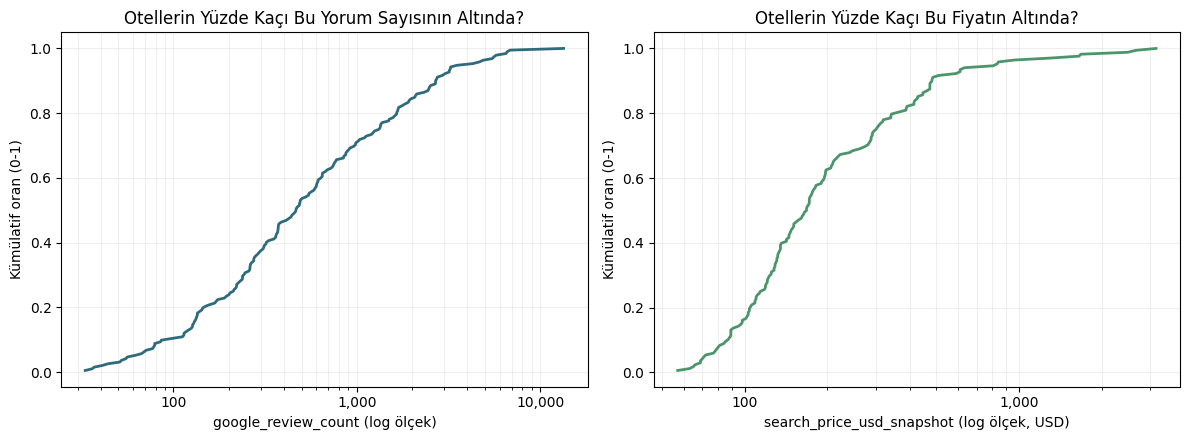

In [139]:
def ecdf(series):
    s = np.sort(series.dropna().values)
    y = np.arange(1, len(s) + 1) / len(s)
    return s, y

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x, y = ecdf(df["google_review_count"])
axes[0].plot(x, y, color=PRIMARY, linewidth=2)
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:,.0f}"))
axes[0].set(title="Otellerin Yüzde Kaçı Bu Yorum Sayısının Altında?",
            xlabel="google_review_count (log ölçek)", ylabel="Kümülatif oran (0-1)")
axes[0].grid(alpha=0.2, which="both")

x, y = ecdf(df["search_price_usd_snapshot"])
axes[1].plot(x, y, color=SECONDARY, linewidth=2)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:,.0f}"))
axes[1].set(title="Otellerin Yüzde Kaçı Bu Fiyatın Altında?",
            xlabel="search_price_usd_snapshot (log ölçek, USD)", ylabel="Kümülatif oran (0-1)")
axes[1].grid(alpha=0.2, which="both")
save_fig(fig, "ecdf_review_count_price.png")
plt.show()

**Bulgu:** ECDF eğrileri her iki değişkenin de düşük-orta bölgede dik, üst uçta uzun ve yatık bir
kuyruk çizdiğini gösteriyor — az sayıda otel çok yüksek değerlerde yer alıyor. Yorum sayısında
eğrinin %75'i 1.323'ün altında kalırken, fiyatta %75'i 302 USD'nin altında kalıyor: her iki
dağılım da klasik "uzun kuyruk" yapısında. Bu, ileride eşik tabanlı özellik/segment
tanımlarında (ör. "popüler otel" = P75 üzeri) neden log ölçek veya persentil kullanmanın ham
değerden daha güvenilir olduğunu gösteriyor.

### 30. İstatistiksel testler (opsiyonel doğrulama)

İki soru veri ve örneklem büyüklüğü açısından basit bir testle sınanabilir:

1. Destinasyonlar arasında rating dağılımları gerçekten farklı mı? (Bölüm 10-11'in görsel
   izlenimini test eder.)
2. `Otel` kategorisi ile diğer kategoriler arasında rating farkı var mı? (Bölüm 8'in görsel
   izlenimini test eder.)

Rating dağılımı normal değil ve grup büyüklükleri eşit olmadığından (Bölüm 3), parametrik
olmayan testler tercih edilir: destinasyonlar için **Kruskal-Wallis** (ikiden fazla bağımsız
grup), kategori karşılaştırması için **Mann-Whitney U** (iki bağımsız grup). p-değeri tek başına
yorumlanmaz; Kruskal-Wallis için epsilon-kare (ε²) etki büyüklüğü de raporlanır.


In [140]:
area_groups = [g["google_rating"].dropna().values for _, g in df.groupby("area")]
h_stat, p_value = stats.kruskal(*area_groups)
k = df["area"].nunique()
n = df["google_rating"].notna().sum()
epsilon_sq = (h_stat - k + 1) / (n - k)

print("Kruskal-Wallis: destinasyonlar arasında google_rating farkı")
print(f"H = {h_stat:.2f}, k = {k} grup, n = {n}, p = {p_value:.4f}")
print(f"Epsilon-kare (etki büyüklüğü) = {epsilon_sq:.3f}")

big_areas = df["area"].value_counts().loc[lambda s: s >= 10].index.tolist()
h_big, p_big = stats.kruskal(*[df.loc[df["area"] == a, "google_rating"].dropna().values for a in big_areas])
print(f"\nDuyarlılık kontrolü - yalnızca n>=10 olan {len(big_areas)} bölge: H = {h_big:.2f}, p = {p_big:.4f}")

Kruskal-Wallis: destinasyonlar arasında google_rating farkı
H = 28.05, k = 14 grup, n = 192, p = 0.0089
Epsilon-kare (etki büyüklüğü) = 0.085

Duyarlılık kontrolü - yalnızca n>=10 olan 11 bölge: H = 26.36, p = 0.0033


In [141]:
otel_ratings = df.loc[df["property_category"] == "Otel", "google_rating"].dropna()
non_otel_ratings = df.loc[df["property_category"] != "Otel", "google_rating"].dropna()
u_stat, p_value_mw = stats.mannwhitneyu(otel_ratings, non_otel_ratings, alternative="two-sided")

print("Mann-Whitney U: Otel (n={}) vs Diğer kategoriler (n={})".format(len(otel_ratings), len(non_otel_ratings)))
print(f"Otel medyan = {otel_ratings.median():.2f}, Diğer medyan = {non_otel_ratings.median():.2f}")
print(f"U = {u_stat:.1f}, p = {p_value_mw:.4f}")

Mann-Whitney U: Otel (n=174) vs Diğer kategoriler (n=18)
Otel medyan = 4.40, Diğer medyan = 4.45
U = 1399.0, p = 0.4558


**Bulgular — İstatistiksel Testler**

- Kruskal-Wallis testi destinasyonlar arasında rating dağılımlarının **istatistiksel olarak
  anlamlı farklılaştığını** gösteriyor (p ≈ 0.009), ve bu sonuç yalnızca n≥10 olan büyük
  bölgelerle tekrarlandığında da korunuyor (p ≈ 0.003) — yani küçük örneklemli bölgeler sonucu
  yapay olarak anlamlı kılmıyor. Ancak etki büyüklüğü (ε² ≈ 0.08) **küçük-orta** düzeyde: bölge,
  rating varyansının yalnızca küçük bir kısmını açıklıyor; istatistiksel anlamlılık pratik
  anlamda büyük bir etki olduğu anlamına gelmiyor.
- `Otel` ile diğer kategoriler arasındaki rating farkı istatistiksel olarak **anlamlı değil**
  (p ≈ 0.46) — Bölüm 8'deki görsel izlenimi doğruluyor. Ancak "Diğer" grubunun kendisi çok
  heterojen (villa, motel, pansiyon, kamping vb. bir arada) olduğundan bu test kaba bir
  karşılaştırmadır.

### 31. Özet Top/Bottom tabloları

Önceki bölümlerde tek tek üretilen sıralamalar burada tek bir referans blokta toplanır; her
tabloda tek metriğe kör sıralama yerine bağlam kolonları (bölge, puan, yorum, fiyat) birlikte
gösterilir. `Potansiyel Değer Otelleri`, Bölüm 28'daki "Düşük Fiyat + Yüksek Rating" çeyreğinin
otel bazında listesidir; kalıcı bir skor değildir.


In [142]:
context_cols = ["hotel_name", "area", "property_category", "google_rating", "google_review_count", "search_price_usd_snapshot"]

print("Top Rated Hotels (>= 200 yorum, Bölüm 6-B ile aynı eşik):")
display(df.loc[df["google_review_count"] >= REVIEW_THRESHOLD]
        .sort_values(["google_rating", "google_review_count"], ascending=[False, False])[context_cols].head(10))

print("\nMost Reviewed Hotels:")
display(df.sort_values("google_review_count", ascending=False)[context_cols].head(10))

print("\nLowest Rated Hotels:")
display(df.sort_values(["google_rating", "google_review_count"], ascending=[True, False])[context_cols].head(10))

print("\nHighest Price Hotels (snapshot):")
display(df.dropna(subset=["search_price_usd_snapshot"]).sort_values("search_price_usd_snapshot", ascending=False)[context_cols].head(10))

Top Rated Hotels (>= 200 yorum, Bölüm 6-B ile aynı eşik):


,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot
74,Benjamin Otel,Gümüşlük,Otel,5.000,487,129.000
10,"Radisson Collection Hotel, Bodrum",Akyarlar,Otel,4.900,3237,273.000
67,Selectum Colours Bodrum,Gümbet,Otel,4.800,13412,473.000
64,Mirada Exclusive Bodrum,Gümbet,Otel,4.800,1905,473.000
151,"Susona Bodrum, LXR Hotels & Resorts",Torba,Resort Otel,4.800,886,482.000
172,Allium Bodrum Resort & Spa,Yalıkavak,Otel,4.800,528,610.000
77,Liman Hotel Gümüslük (Adult only),Gümüşlük,Otel,4.800,411,134.000
190,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,Otel,4.800,267,832.000
147,Rixos Premium Bodrum,Torba,Otel,4.700,4889,NaN
155,Voyage Torba,Torba,Otel,4.700,2753,"2,660.000"



Most Reviewed Hotels:


,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot
67,Selectum Colours Bodrum,Gümbet,Otel,4.800,13412,473.000
102,Green Bay Resort & Spa Bodrum,Güvercinlik,Otel,4.500,6843,179.000
105,La Blanche Island Bodrum,Güvercinlik,Otel,4.300,6594,289.000
11,Selectum Collection Bodrum,Akyarlar,Otel,4.500,6514,387.000
159,La Blanche Resort Bodrum,Turgutreis,Otel,4.600,5754,391.000
114,Yasmin Bodrum Resort,Kadıkalesi,Otel,4.300,5589,446.000
140,DUJA BODRUM,Torba,Otel,4.400,5479,610.000
147,Rixos Premium Bodrum,Torba,Otel,4.700,4889,NaN
109,Titanic Luxury Collection Bodrum,Güvercinlik,Otel,4.600,4656,NaN
6,Kefaluka Resort,Akyarlar,Otel,4.400,4293,NaN



Lowest Rated Hotels:


,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot
103,Greenport Bodrum,Güvercinlik,Otel,3.200,1317,98.000
36,Bodrum Bay Resort,Bodrum Merkez,Otel,3.300,1825,414.000
27,Mira Beach Resort Bodrum,Bitez,Otel,3.300,274,72.000
68,Siesta Beach Apart,Gümbet,Resort Otel,3.400,502,65.000
129,Petunya Beach Resort,Ortakent-Yahşi,Otel,3.700,2687,NaN
57,Bodrum Beach Resort,Gümbet,Otel,3.700,1678,69.000
69,The Luvi Hotel,Gümbet,Otel,3.700,1226,121.000
19,Bitez Risa Hotel,Bitez,Otel,3.700,919,89.000
58,Bodrum Hotel Baba,Gümbet,Otel,3.700,465,77.000
137,Bodrum Blue Bay Otel,Torba,Otel,3.700,51,120.000



Highest Price Hotels (snapshot):


,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot
164,Caja by Maxx Royal,Türkbükü,Otel,4.600,135,"3,158.000"
155,Voyage Torba,Torba,Otel,4.700,2753,"2,660.000"
156,Voyage Torba Private,Torba,Otel,4.700,548,"2,489.000"
55,"Mandarin Oriental, Bodrum",Göltürkbükü,Otel,4.700,2728,"1,679.000"
20,"Caresse, a Luxury Collection Resort & Spa, Bodrum",Bitez,Otel,4.500,904,"1,654.000"
15,Xanadu Island,Akyarlar,Otel,4.600,2068,"1,301.000"
111,Azure By Yelken Hotel,Kadıkalesi,Otel,4.400,565,962.000
188,The Bodrum EDITION,Yalıkavak,Otel,4.400,1016,841.000
190,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,Otel,4.800,267,832.000
168,MACAKIZI BODRUM,Türkbükü,Otel,4.300,1247,805.000


In [143]:
area_context_cols = ["area", "hotel_count", "avg_rating", "median_rating", "median_reviews_per_hotel", "median_price"]
area_full = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    avg_rating=("google_rating", "mean"),
    median_rating=("google_rating", "median"),
    median_reviews_per_hotel=("google_review_count", "median"),
    median_price=("search_price_usd_snapshot", "median"),
)

print("Best Rated Destinations:")
display(area_full.sort_values("avg_rating", ascending=False)[area_context_cols[1:]])

print("\nMost Popular Destinations (otel başına medyan yorum):")
display(area_full.sort_values("median_reviews_per_hotel", ascending=False)[area_context_cols[1:]])

print("\nHighest Median Price Destinations:")
display(area_full.sort_values("median_price", ascending=False)[area_context_cols[1:]])

Best Rated Destinations:


,hotel_count,avg_rating,median_rating,median_reviews_per_hotel,median_price
area,,,,,
Gündoğan,14,4.586,4.500,275.000,189.500
Gümüşlük,15,4.507,4.500,276.000,106.000
Göltürkbükü,10,4.480,4.450,318.000,165.000
Yalıkavak,22,4.464,4.450,296.000,329.500
Akyarlar,16,4.450,4.400,"1,056.000",192.500
Türkbükü,6,4.450,4.450,537.000,532.000
Turgutreis,7,4.429,4.600,"1,608.000",123.500
Torba,21,4.367,4.400,372.000,248.000
Bodrum Merkez,13,4.300,4.300,"1,575.000",169.000



Most Popular Destinations (otel başına medyan yorum):


,hotel_count,avg_rating,median_rating,median_reviews_per_hotel,median_price
area,,,,,
Kadıkalesi,4,4.300,4.350,"2,683.000",446.000
Turgutreis,7,4.429,4.600,"1,608.000",123.500
Bodrum Merkez,13,4.300,4.300,"1,575.000",169.000
Gümbet,15,4.093,4.000,"1,489.000",128.000
Güvercinlik,10,4.160,4.250,"1,082.500",162.500
Akyarlar,16,4.450,4.400,"1,056.000",192.500
Bitez,18,4.228,4.350,624.000,131.500
Türkbükü,6,4.450,4.450,537.000,532.000
Torba,21,4.367,4.400,372.000,248.000



Highest Median Price Destinations:


,hotel_count,avg_rating,median_rating,median_reviews_per_hotel,median_price
area,,,,,
Türkbükü,6,4.450,4.450,537.000,532.000
Kadıkalesi,4,4.300,4.350,"2,683.000",446.000
Yalıkavak,22,4.464,4.450,296.000,329.500
Torba,21,4.367,4.400,372.000,248.000
Akyarlar,16,4.450,4.400,"1,056.000",192.500
Gündoğan,14,4.586,4.500,275.000,189.500
Bodrum Merkez,13,4.300,4.300,"1,575.000",169.000
Göltürkbükü,10,4.480,4.450,318.000,165.000
Güvercinlik,10,4.160,4.250,"1,082.500",162.500


In [144]:
print("Potansiyel Değer Otelleri (Düşük Fiyat + Yüksek Rating çeyreği, Bölüm 28):")
display(low_price_high_rating.sort_values(["google_rating", "google_review_count"], ascending=[False, False])[context_cols])

Potansiyel Değer Otelleri (Düşük Fiyat + Yüksek Rating çeyreği, Bölüm 28):


,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot
74,Benjamin Otel,Gümüşlük,Otel,5.000,487,129.000
28,Mumu Bodrum Hotel,Bitez,Otel,4.900,71,133.000
77,Liman Hotel Gümüslük (Adult only),Gümüşlük,Otel,4.800,411,134.000
98,Villa Oliva Butik Otel,Gündoğan,Otel,4.800,168,123.000
43,Noa Suite Hotel,Bodrum Merkez,Otel,4.800,98,71.000
73,Begonvil Gümüşlük,Gümüşlük,Kamping Bungalov,4.800,36,151.000
45,Senses Hotel,Bodrum Merkez,Otel,4.700,1035,148.000
86,Wanderheaven Camping & Tiny House Bodrum,Gümüşlük,Otel,4.700,613,80.000
99,Villa Rustica Hotel,Gündoğan,Otel,4.700,243,145.000
47,Babana Hotel,Göltürkbükü,Otel,4.700,221,132.000


**Bulgu:** Bu tablolar tek başına yeni bir bulgu üretmiyor; önceki bölümlerin (5, 6, 10, 12, 18,
29) referans amaçlı bir özeti niteliğinde ve `reports/` altına kaydedilecek dosyaların
(`eda_hotel_summary.csv`, `eda_destination_profile.csv`) temelini oluşturuyor.

### 32. Destinasyon profil tablosu

Her destinasyon için tek satırlık bir profil oluşturulur ve `reports/eda_destination_profile.csv`
olarak kaydedilir. `dominant_property_category`, o bölgede en sık görülen konaklama tipidir
(Bölüm 21'de görüldüğü gibi çoğu bölgede `Otel`).


In [145]:
destination_profile = df.groupby("area").agg(
    hotel_count=("hotel_id", "size"),
    avg_rating=("google_rating", "mean"),
    median_rating=("google_rating", "median"),
    total_reviews=("google_review_count", "sum"),
    median_reviews=("google_review_count", "median"),
    price_n=("search_price_usd_snapshot", lambda s: s.notna().sum()),
    median_price=("search_price_usd_snapshot", "median"),
    mean_price=("search_price_usd_snapshot", "mean"),
).reset_index()

dominant_category = (
    df.groupby("area")["property_category"]
    .agg(lambda s: s.value_counts().idxmax())
    .rename("dominant_property_category")
)
destination_profile = destination_profile.merge(dominant_category, on="area").sort_values("avg_rating", ascending=False)
display(destination_profile)

,area,hotel_count,avg_rating,median_rating,total_reviews,median_reviews,price_n,median_price,mean_price,dominant_property_category
6,Gündoğan,14,4.586,4.500,6520,275.000,14,189.500,211.214,Otel
5,Gümüşlük,15,4.507,4.500,4166,276.000,13,106.000,102.308,Otel
3,Göltürkbükü,10,4.480,4.450,6008,318.000,10,165.000,311.900,Otel
13,Yalıkavak,22,4.464,4.450,9571,296.000,22,329.500,355.045,Otel
0,Akyarlar,16,4.450,4.400,27426,"1,056.000",12,192.500,284.417,Otel
12,Türkbükü,6,4.450,4.450,3670,537.000,6,532.000,956.000,Otel
11,Turgutreis,7,4.429,4.600,14095,"1,608.000",6,123.500,182.833,Otel
10,Torba,21,4.367,4.400,23707,372.000,17,248.000,532.647,Otel
2,Bodrum Merkez,13,4.300,4.300,18174,"1,575.000",13,169.000,242.846,Otel
8,Kadıkalesi,4,4.300,4.350,11520,"2,683.000",3,446.000,583.667,Otel


### 33. Otel düzeyinde EDA özet tablosu

Otel seviyesinde en sık kullanılan kolonlardan sade bir özet tablo üretilir ve
`reports/eda_hotel_summary.csv` olarak kaydedilir. Ana `hotels_features.csv` **değiştirilmez**.


In [146]:
hotel_summary = df[[
    "hotel_id", "hotel_name", "area", "property_category",
    "google_rating", "google_review_count", "search_price_usd_snapshot",
    "has_official_star_rating", "has_price_snapshot",
]].copy()
display(hotel_summary.head())
print(f"hotel_summary: {hotel_summary.shape[0]} satır, {hotel_summary.shape[1]} kolon")

,hotel_id,hotel_name,area,property_category,google_rating,google_review_count,search_price_usd_snapshot,has_official_star_rating,has_price_snapshot
0,BOD001,Aksoy Taş Ev,Akyarlar,Otel,4.700,135,194.000,False,True
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,Otel,4.200,3197,191.000,False,True
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,Otel,4.300,246,57.000,False,True
3,BOD004,Bendis Beach Hotel,Akyarlar,Otel,3.900,2469,104.000,False,True
4,BOD005,ByAkkan,Akyarlar,Otel,4.400,203,84.000,False,True


hotel_summary: 192 satır, 9 kolon


### 34. Rapor ve figür çıktılarının kaydedilmesi

Önemli EDA tabloları `reports/` altına, önemli grafikler ise `reports/figures/eda/` altına
zaten her üretildikleri hücrede (`save_fig`) kaydedilmiş durumda. Burada yalnızca tablo
çıktıları toplu biçimde yazılır. Ana ve temiz veri dosyaları (`hotels_clean.csv`,
`hotels_features.csv`) bu notebookta hiçbir noktada üzerine yazılmaz.


In [147]:
output_paths = {
    "eda_hotel_summary": REPORTS_DIR / "eda_hotel_summary.csv",
    "eda_destination_profile": REPORTS_DIR / "eda_destination_profile.csv",
    "eda_top_rated_hotels": REPORTS_DIR / "eda_top_rated_hotels.csv",
    "eda_most_reviewed_hotels": REPORTS_DIR / "eda_most_reviewed_hotels.csv",
    "eda_lowest_rated_hotels": REPORTS_DIR / "eda_lowest_rated_hotels.csv",
    "eda_highest_price_hotels": REPORTS_DIR / "eda_highest_price_hotels.csv",
    "eda_potential_value_hotels": REPORTS_DIR / "eda_potential_value_hotels.csv",
}

hotel_summary.to_csv(output_paths["eda_hotel_summary"], index=False, encoding="utf-8-sig")
destination_profile.to_csv(output_paths["eda_destination_profile"], index=False, encoding="utf-8-sig")

df.loc[df["google_review_count"] >= REVIEW_THRESHOLD].sort_values(
    ["google_rating", "google_review_count"], ascending=[False, False]
)[context_cols].to_csv(output_paths["eda_top_rated_hotels"], index=False, encoding="utf-8-sig")

df.sort_values("google_review_count", ascending=False)[context_cols].head(20).to_csv(
    output_paths["eda_most_reviewed_hotels"], index=False, encoding="utf-8-sig"
)

df.sort_values(["google_rating", "google_review_count"], ascending=[True, False])[context_cols].head(10).to_csv(
    output_paths["eda_lowest_rated_hotels"], index=False, encoding="utf-8-sig"
)

df.dropna(subset=["search_price_usd_snapshot"]).sort_values("search_price_usd_snapshot", ascending=False)[context_cols].head(15).to_csv(
    output_paths["eda_highest_price_hotels"], index=False, encoding="utf-8-sig"
)

low_price_high_rating.sort_values(["google_rating", "google_review_count"], ascending=[False, False])[context_cols].to_csv(
    output_paths["eda_potential_value_hotels"], index=False, encoding="utf-8-sig"
)

display(pd.DataFrame([
    {"output": name, "path": str(path.relative_to(PROJECT_ROOT))} for name, path in output_paths.items()
]))

saved_figures = sorted(FIGURES_DIR.glob("*.png"))
print(f"\n{len(saved_figures)} figür {FIGURES_DIR.relative_to(PROJECT_ROOT)} altına kaydedildi.")

,output,path
0,eda_hotel_summary,reports/eda_hotel_summary.csv
1,eda_destination_profile,reports/eda_destination_profile.csv
2,eda_top_rated_hotels,reports/eda_top_rated_hotels.csv
3,eda_most_reviewed_hotels,reports/eda_most_reviewed_hotels.csv
4,eda_lowest_rated_hotels,reports/eda_lowest_rated_hotels.csv
5,eda_highest_price_hotels,reports/eda_highest_price_hotels.csv
6,eda_potential_value_hotels,reports/eda_potential_value_hotels.csv



23 figür reports/figures/eda altına kaydedildi.


# Key Findings

Notebook boyunca gerçek çalıştırma çıktılarından elde edilen bulgular:

**Rating ve yorum yapısı**

1. Google puanları sola çarpık biçimde 4.0-4.8 bandında yoğunlaşıyor (medyan 4.40, ortalama
   4.36, skew ≈ -0.72); düşük puanlı (≤3.5) yalnızca 4 otel var.
2. Yorum sayısı aşırı sağa çarpık (skew ≈ 4.9, medyan 466, maksimum 13.412); log1p dönüşümü
   bu çarpıklığı büyük ölçüde düzeltiyor.
3. Rating ile yorum sayısı arasında pratikte anlamlı bir ilişki yok (Pearson r ≈ -0.01,
   Spearman ρ ≈ -0.17) — popülerlik yüksek puanı garanti etmiyor.
4. Az yorumlu yüksek puanlı oteller (Bölüm 6, 20) ile çok yorumlu orta puanlı büyük resortlar
   arasındaki fark, ham rating'in tek başına güvenilir olmadığını gösteriyor; 200 yorum eşiği
   uygulandığında Top 10 listesi belirgin biçimde değişiyor.

**Destinasyon düzeyi**

5. Arz üç bölgede yoğunlaşıyor: Yalıkavak (22), Ortakent-Yahşi (21), Torba (21); Kadıkalesi (4)
   ve Türkbükü (6) çok küçük örneklemli.
6. Destinasyonlar arasındaki rating farkı Kruskal-Wallis testiyle istatistiksel olarak anlamlı
   (p ≈ 0.009, n≥10 alt kümede p ≈ 0.003), ama etki büyüklüğü küçük-orta (ε² ≈ 0.08).
7. Gündoğan (4.59) ve Gümüşlük (4.51) en yüksek ortalama puanlı; Gümbet (4.09) ve Güvercinlik
   (4.16) en düşük ortalamalı büyük örneklemli bölgeler.
8. Toplam yorum sayısına göre popülerlik sıralaması, otel başına medyan yoruma göre sıralamadan
   tamamen farklı sonuç veriyor — ölçek etkisi gerçek ve gözden kaçırılmamalı.
9. Kalite-popülerlik matrisinde yalnızca Akyarlar ve Turgutreis "Yüksek Puan + Yüksek
   Popülerlik" çeyreğinde; bunlar bu veri setindeki en dengeli iki destinasyon.

**Fiyat (yalnızca 2026-08-24 snapshot bağlamı)**

10. Fiyat snapshot'ı 168/192 otelde mevcut, aşırı sağa çarpık (medyan 168 USD, ortalama 292 USD,
    maksimum 3.158 USD).
11. Fiyat ile rating arasında zayıf-orta pozitif ilişki var (Pearson r ≈ 0.23, Spearman ρ ≈
    0.35); fiyat ile yorum sayısı arasında ise neredeyse ilişki yok (r ≈ 0.13-0.15).
12. Destinasyon düzeyinde de "daha pahalı = daha memnun müşteri" ilişkisi zayıf (r ≈ 0.18,
    n=14); en yüksek medyan fiyatlı bölgeler (Türkbükü, Kadıkalesi) en yüksek ortalama puanlı
    bölgeler değil.
13. "Düşük Fiyat + Yüksek Rating" çeyreğinde 35 otel var — ileride bir fiyat/performans
    özelliği için doğal aday havuzu.

**Veri kalitesi ve kapsam sınırları**

14. `official_star_rating` 192/192 kayıtta tamamen eksik; bu notebookta hiçbir yerde
    Google puanından türetilmedi, veri yetersizliği nedeniyle ilgili analizler (Bölüm 23)
    atlandı.
15. `business_status` 191/192 kayıtta eksik; eksiklik "otel kapalı" olarak yorumlanmadı,
    yalnızca "veri toplanmamış" olarak bırakıldı.
16. Konaklama kategorisi son derece dengesiz (`Otel` n=174 vs. diğer 12 kategori toplamda
    n=18); `Otel` ile diğer kategoriler arasında rating farkı istatistiksel olarak anlamlı
    değil (Mann-Whitney p ≈ 0.46), ama bu sonuç küçük ve heterojen "Diğer" grubu nedeniyle
    temkinli okunmalı.


# Questions for Next Stages

Bu EDA'dan doğan ve sonraki Feature Engineering / ML aşamalarına rehberlik edecek sorular:

- Rating ile yorum sayısı arasında sistematik bir ilişki yokken, güvenilirlik ayarlı (Bayesian /
  weighted) bir rating skoru resmi olarak Feature Engineering'e eklenmeli mi, yoksa ham rating +
  yorum sayısı ayrı iki sinyal olarak mı bırakılmalı?
- Destinasyon farkı istatistiksel olarak anlamlı ama etkisi küçük (ε² ≈ 0.08) — bölge, bir
  rating tahmin modelinde ne kadar açıklayıcı güç katar? Diğer hangi değişkenler (fiyat,
  kategori) birlikte modele girerse açıklayıcılık artar?
- Fiyat/performans (`value_score`) nasıl tanımlanmalı: global medyanlara göre mi (Bölüm 28),
  yoksa zaten mevcut olan bölge-içi persentil kolonlarına (`price_percentile_within_area`,
  `rating_gap_from_area_median`) göre mi?
- Oteller doğal olarak hangi segmentlere ayrılıyor? Bölüm 27'deki dört-çeyrekli
  rating-popülerlik yapısı, ileride bir kümeleme (clustering) çalışmasının başlangıç hipotezi
  olabilir mi?
- Destinasyonlar turizm profiline göre (ör. "sakin/butik" vs "yoğun/popüler") segmentlere
  ayrılabilir mi? Bölüm 13'teki dört-çeyrekli yapı bu segmentasyon için yeterli mi, yoksa daha
  fazla değişken (fiyat, kategori karışımı) mı gerekiyor?
- `official_star_rating` eksikliği (192/192) dış bir kaynaktan (resmî işletme belgesi listesi)
  doldurulabilir mi? Doldurulursa Google rating ile ne ölçüde örtüşür/ayrışır?
- Kadıkalesi ve Türkbükü gibi küçük örneklemli destinasyonlar için ek veri toplama önceliği var
  mı, yoksa bu bölgeler analizde her zaman "düşük güven" etiketiyle mi taşınmalı?
- Fiyatı en fazla hangi özellikler açıklıyor (bölge, kategori, rating, yorum hacmi)? Bu soru
  `06_price_analysis.ipynb` içinde ayrıntılı ele alınacak.


### Sonuç

- 192 otel, `hotels_features.csv` üzerinden hiçbir kaynak kolon değiştirilmeden incelendi;
  notebook boyunca eklenen geçici kolonlar (`rating_bucket`, `category_grouped`,
  `hotel_quadrant` vb.) hiçbir dosyaya kalıcı olarak yazılmadı.
- Rating, yorum sayısı ve fiyat birbirinden büyük ölçüde bağımsız sinyaller taşıyor; hiçbiri
  diğerini güçlü biçimde açıklamıyor (Bölüm 22).
- Destinasyon farkı istatistiksel olarak gerçek ama etkisi mütevazı; kategori farkı bu veri
  setinde anlamlı değil.
- Resmî yıldız ve business status alanları veri yetersizliği nedeniyle analiz dışı bırakıldı,
  doldurulmadı veya yanlış yorumlanmadı.
- 7 EDA raporu `reports/` altına, 26 grafik `reports/figures/eda/` altına kaydedildi (bkz.
  Bölüm 34 çıktısı).
- Sonraki aşama, fiyatın ayrıntılı biçimde ele alınacağı `06_price_analysis.ipynb`; bu notebookta
  üretilen "Questions for Next Stages" listesi hem o notebook hem de ileriki Feature
  Engineering/ML aşamaları için başlangıç noktasıdır.
